# [LAB-02] 3. KMeans 튜닝・평가

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, crosstab
import numpy as np

# 엘보우 포인트를 자동으로 찾아주는 라이브러리
from kneed import KneeLocator

# 실루엣 지표
from sklearn.metrics import silhouette_samples, silhouette_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기

- 앞 단원의 게임 데이터는 변수가 `time spent`, `game level` **두 개뿐**이라 산점도만 봐도 몇 덩어리인지 대충 보였다.
- 이번에는 변수가 **네 개**인 `iris`(붓꽃 150송이)를 쓴다. 4차원은 눈으로 볼 수 없으므로, **눈 대신 지표가 필요해진다.**

> `iris` 에는 실제 품종(`Species`)이 함께 들어 있다.
> 군집분석은 이 정답을 **쓰지 않지만**, 단원 마지막에 "지표만 보고 정한 K가 쓸 만했는지" 확인하는 용도로 활용한다.

In [2]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


### 3. 데이터 전처리

군집분석은 정답을 보지 않는다. 종속변수 `Species` 를 제외한 데이터를 추출한다.

In [3]:
df = origin.drop("Species", axis=1)
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.100,3.500,1.400,0.200
1,4.900,3.000,1.400,0.200
2,4.700,3.200,1.300,0.200
3,4.600,3.100,1.500,0.200
4,5.000,3.600,1.400,0.200


## #02. 엘보우 포인트 방법

### 1.  K를 2부터 10까지 늘려 가며 군집을 수행하고 이너셔 수집

- 학습이 끝난 모델의 `estimator.inertia_` 에 이너셔 값이 들어 있다.
- `my_cluster.kmeans()` 는 `(모델, 군집번호가 붙은 데이터, 중심점)` 세 가지를 돌려준다.
  - 여기서는 모델만 쓰면 되므로 나머지는 `_` 로 받고, 그래프도 `plot=False` 로 끈다.

In [4]:
klist = list(range(2, 11))
inertia = []   # 각 K에 대한 이너셔를 담을 리스트

for k in klist:
    estimator, _, _ = my_cluster.kmeans(df, k=k, plot=False, verbose=False)
    inertia.append(estimator.inertia_)

DataFrame({"k": klist, "inertia": inertia}).T

,0,1,2,3,4,5,6,7,8
k,2.000,3.000,4.000,5.000,6.000,7.000,8.000,9.000,10.000
inertia,222.362,140.902,114.627,91.048,81.707,70.697,65.453,56.962,47.275


### 2. 이너셔 값의 변화 시각화

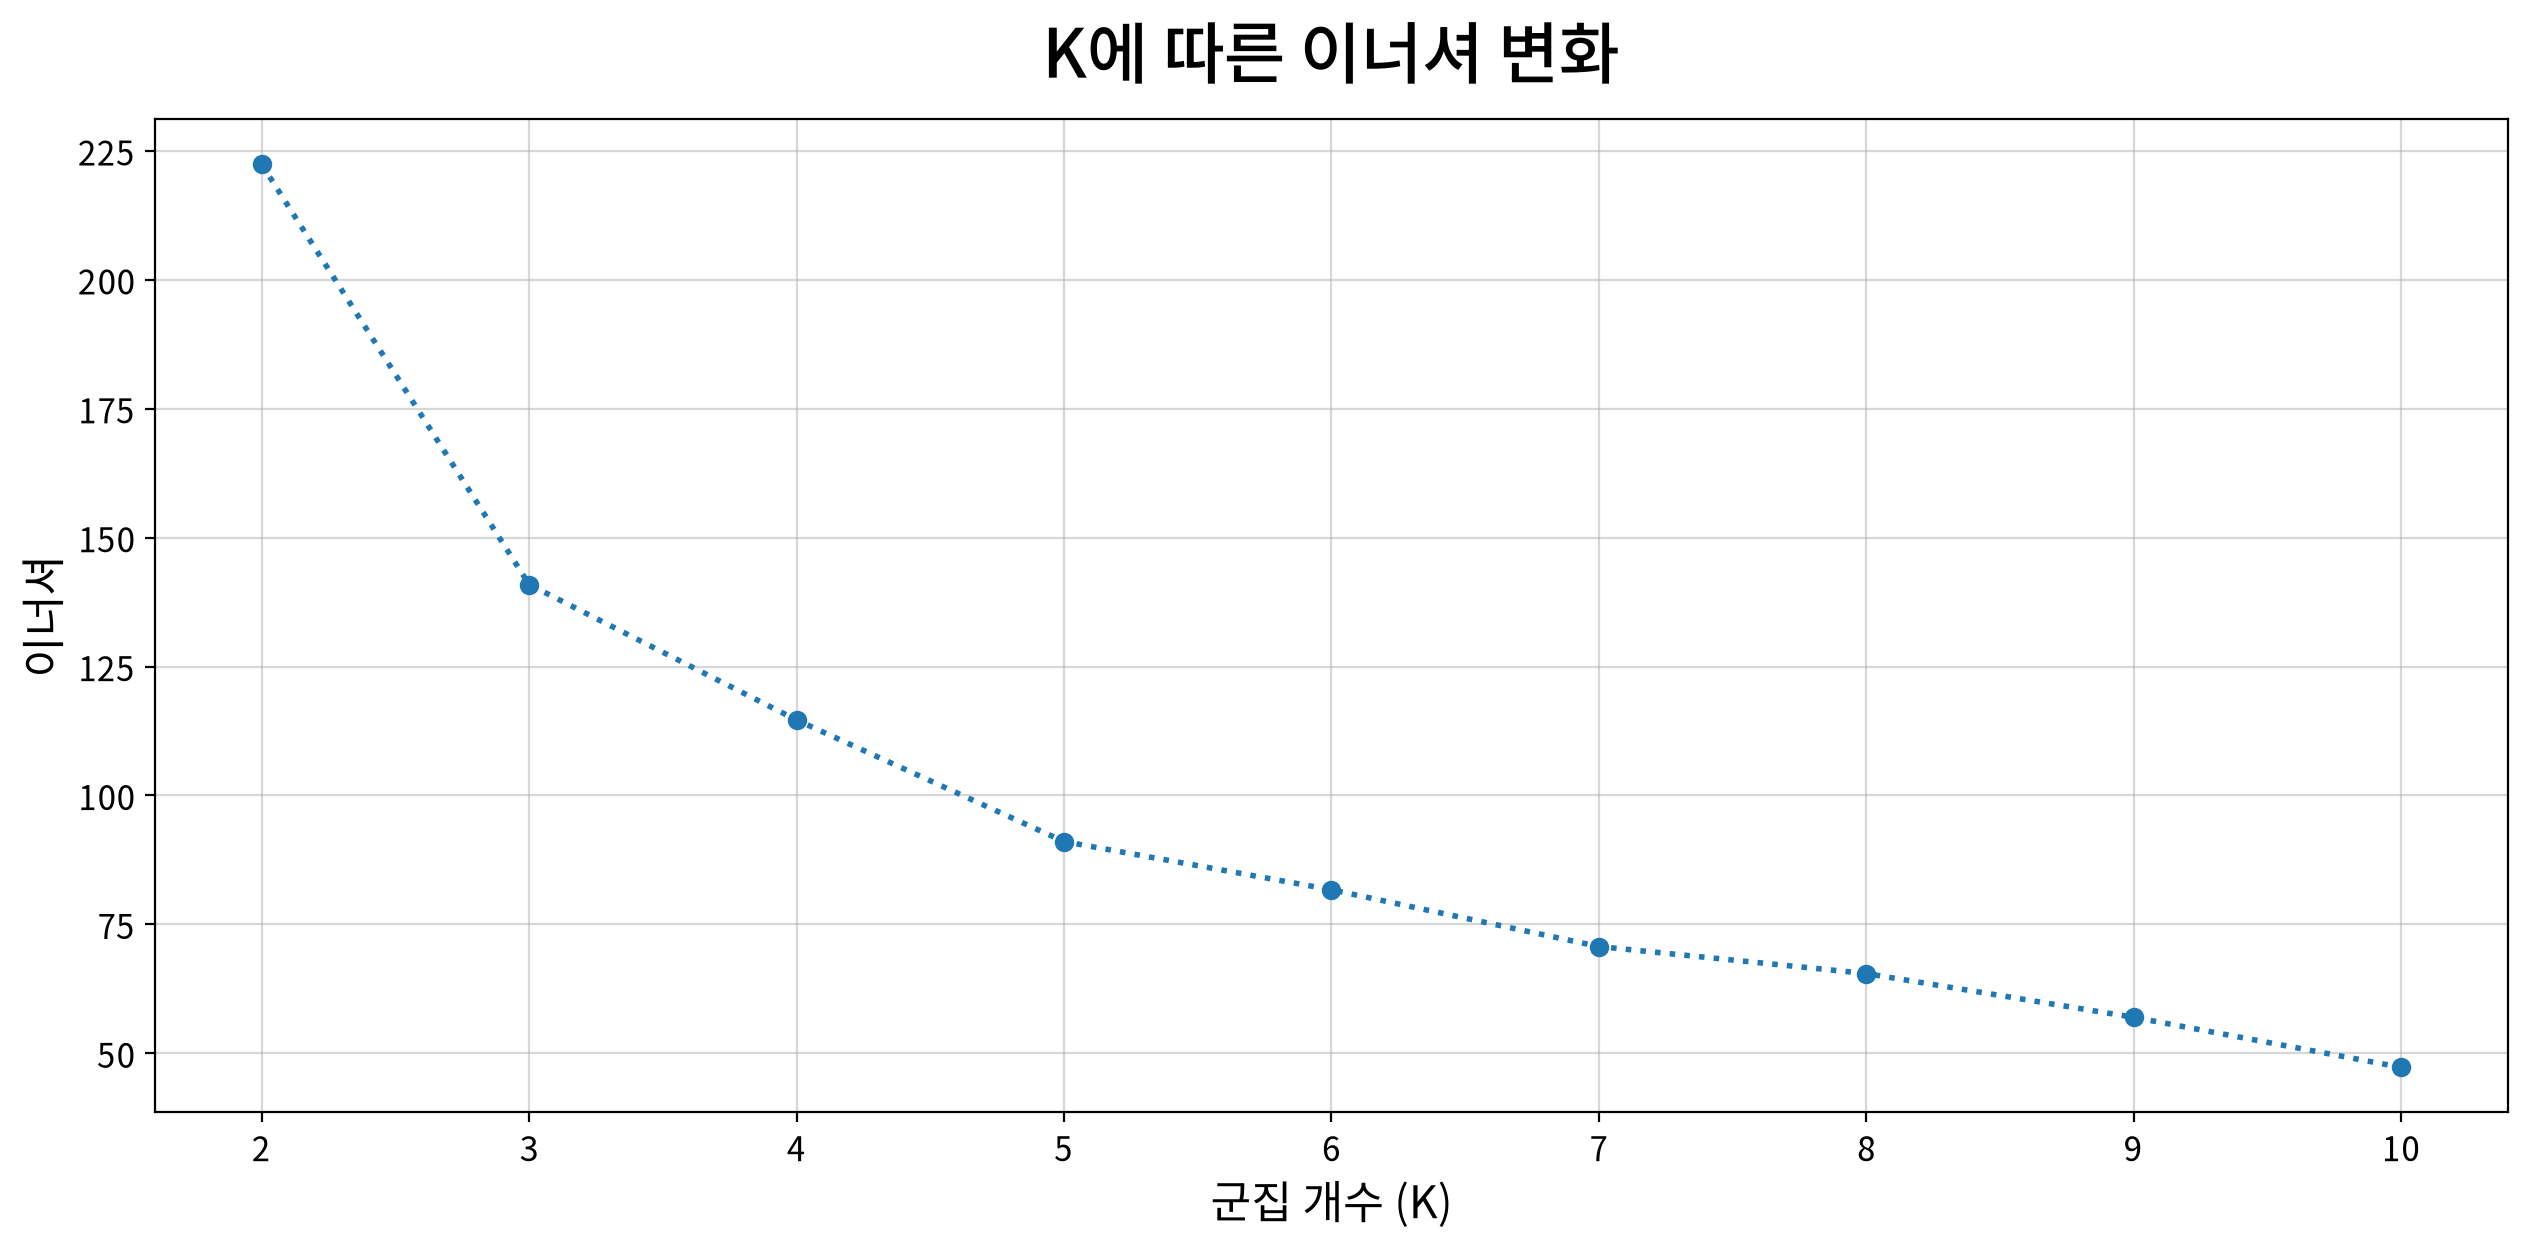

In [5]:
my_plot.lineplot(x=klist, y=inertia, marker="o", linestyle=":",
                 title="K에 따른 이너셔 변화",
                 xlabel="군집 개수 (K)", ylabel="이너셔")

##### 💡 인사이트

- K가 커지면 이너셔는 **무조건 줄어든다.**
- 그래서 "이너셔가 가장 작은 K"를 고르는 것은 의미가 없다. 대신 **줄어드는 속도가 확 꺾이는 지점**을 찾는다.
- 그래프를 보면 K가 `2 → 3` 으로 갈 때는 뚝 떨어지지만, 그 뒤로는 완만해진다.
- **이렇게 꺾이는 지점이 팔꿈치(Elbow)를 닮았다고 해서 엘보우 포인트라고 부른다.**

### 3. KneeLocator 라이브러리 활용 - 엘보우 포인트 구하기

| 파라미터 | 값 | 의미 |
|---|---|---|
| `curve` | `convex` | 아래로 볼록한 곡선 (이너셔 그래프가 이 모양) |
| `curve` | `concave` | 위로 볼록한 곡선 |
| `direction` | `decreasing` | x가 커질수록 y가 작아짐 (이너셔가 이 경우) |
| `direction` | `increasing` | x가 커질수록 y가 커짐 |
| `S` | 숫자 | 민감도. 작을수록 작은 꺾임에도 반응한다 |

In [6]:
kl = KneeLocator(klist, inertia, curve="convex", 
                 direction="decreasing", S=0.01)

print("엘보우 포인트(자동):", kl.elbow)
print("그 지점의 이너셔:", round(kl.elbow_y, 2))

엘보우 포인트(자동): 5
그 지점의 이너셔: 91.05


### 4. 엘보우 포인트 시각화

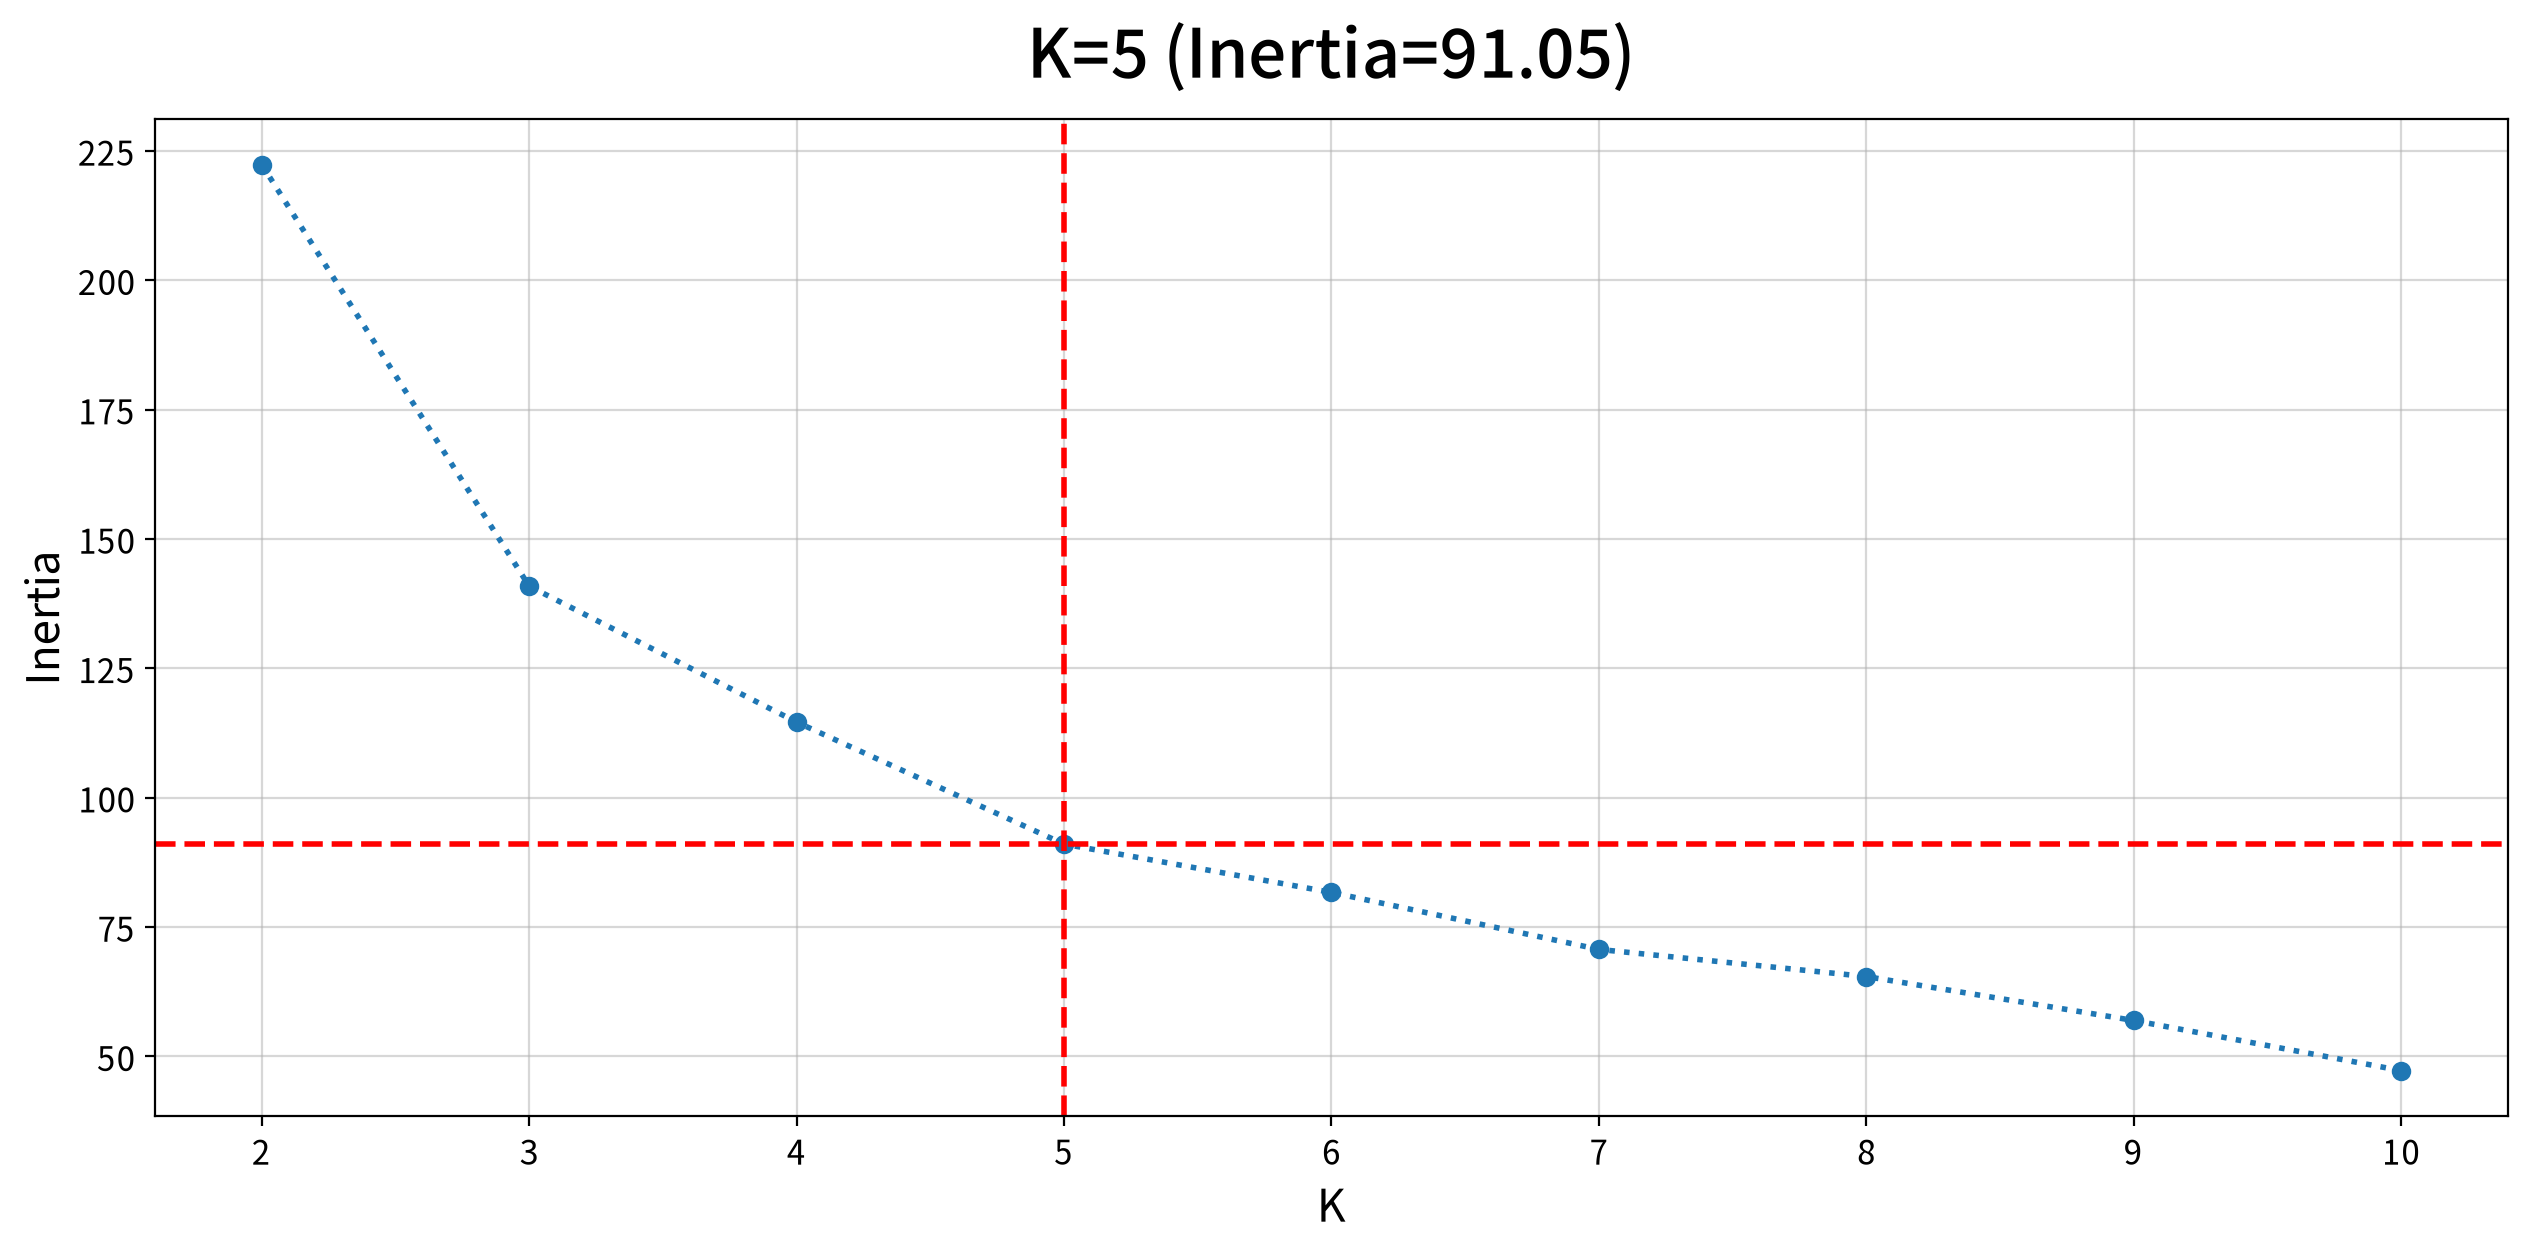

In [7]:
fig, ax = my_plot.init(
        title=f"K={kl.elbow} (Inertia={round(kl.elbow_y, 2)})", xlabel="K", ylabel="Inertia")

my_plot.lineplot(x=klist, y=inertia, marker="o", linestyle=":",ax=ax)

ax.axvline(x=kl.elbow, color="red", linestyle="--")
ax.axhline(y=kl.elbow_y, color="red", linestyle="--")

my_plot.show()

#### ⚠️ 엘보우 포인트의 한계

| 한계 | 설명 |
|---|---|
| 꺾이는 지점이 애매할 때가 많다 | 완만한 곡선이면 사람마다 다르게 읽는다 |
| 군집의 **품질**은 알려주지 않는다 | "잘 나뉘었는가"가 아니라 "얼마나 뭉쳤는가"만 본다 |
| 결국 후보를 좁혀줄 뿐이다 | 최종 결정은 다른 지표가 필요하다 |

> 이너셔는 **"그룹 안에 얼마나 뭉쳤나"** 만 본다.
> 옆 그룹과 **떨어져 있는지**는 전혀 보지 않는다. 뭉쳐 있어도 옆 그룹과 붙어 있으면 좋은 군집이 아니다.
>
> 그래서 다음 단계로 **실루엣 스코어**가 필요하다.

## #03. 실루엣 스코어

### 1. 데이터 하나하나의 실루엣 계수 확인

- 엘보우로 확인된 K=5 상태에서 각 데이터의 실루엣 계수 확인

In [8]:
estimator, _, _ = my_cluster.kmeans(df, k=5, scaling='standard',
                                    plot=False, verbose=False)
cluster = estimator.labels_
sdf = my_prep.scaling(df, method='standard')
sdf.head()

# 각 데이터 포인트의 실루엣 계수
s_samples = silhouette_samples(X=sdf, labels=cluster)

check_df = DataFrame({"cluster": cluster, "실루엣계수": s_samples})
display(check_df.head(10).T)

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90          -1.87 ~ 2.49
Sepal.Width          2.00 ~ 4.40          -2.43 ~ 3.09
Petal.Length         1.00 ~ 6.90          -1.57 ~ 1.79
Petal.Width          0.10 ~ 2.50          -1.45 ~ 1.71


,0,1,2,3,4,5,6,7,8,9
cluster,1.000,4.000,4.000,4.000,1.000,1.000,4.000,1.000,4.000,4.000
실루엣계수,0.352,0.630,0.593,0.656,0.443,0.567,0.236,-0.010,0.601,0.612


### 2. K=5일 때의 실루엣 스코어 (평균 실루엣 계수)

In [9]:
s_score = silhouette_score(X=sdf, labels=cluster)
print("k=5일 때의 실루엣 스코어:", round(s_score, 4))

k=5일 때의 실루엣 스코어: 0.345


### 3. K를 바꿔 가며 실루엣 스코어 비교

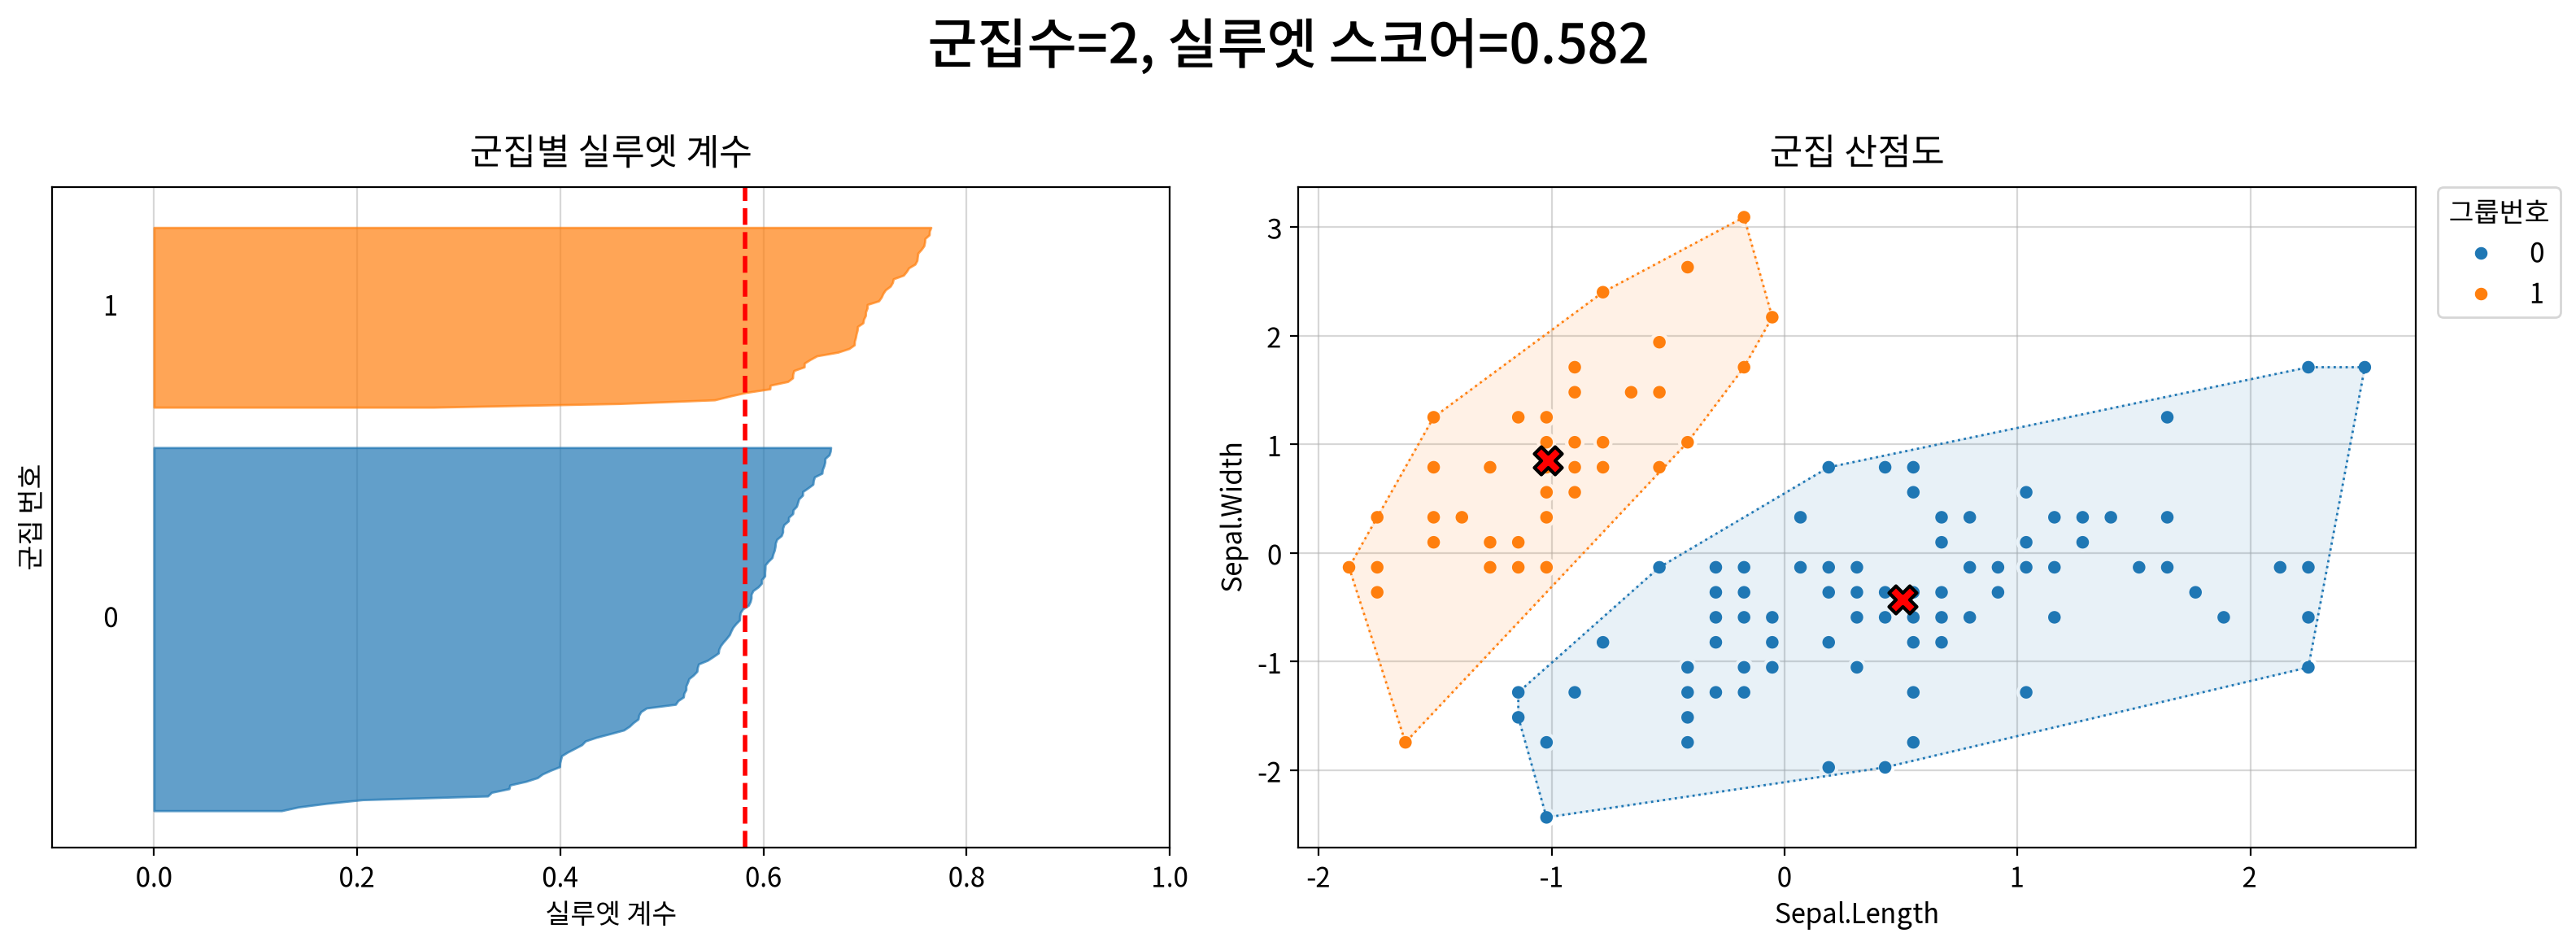

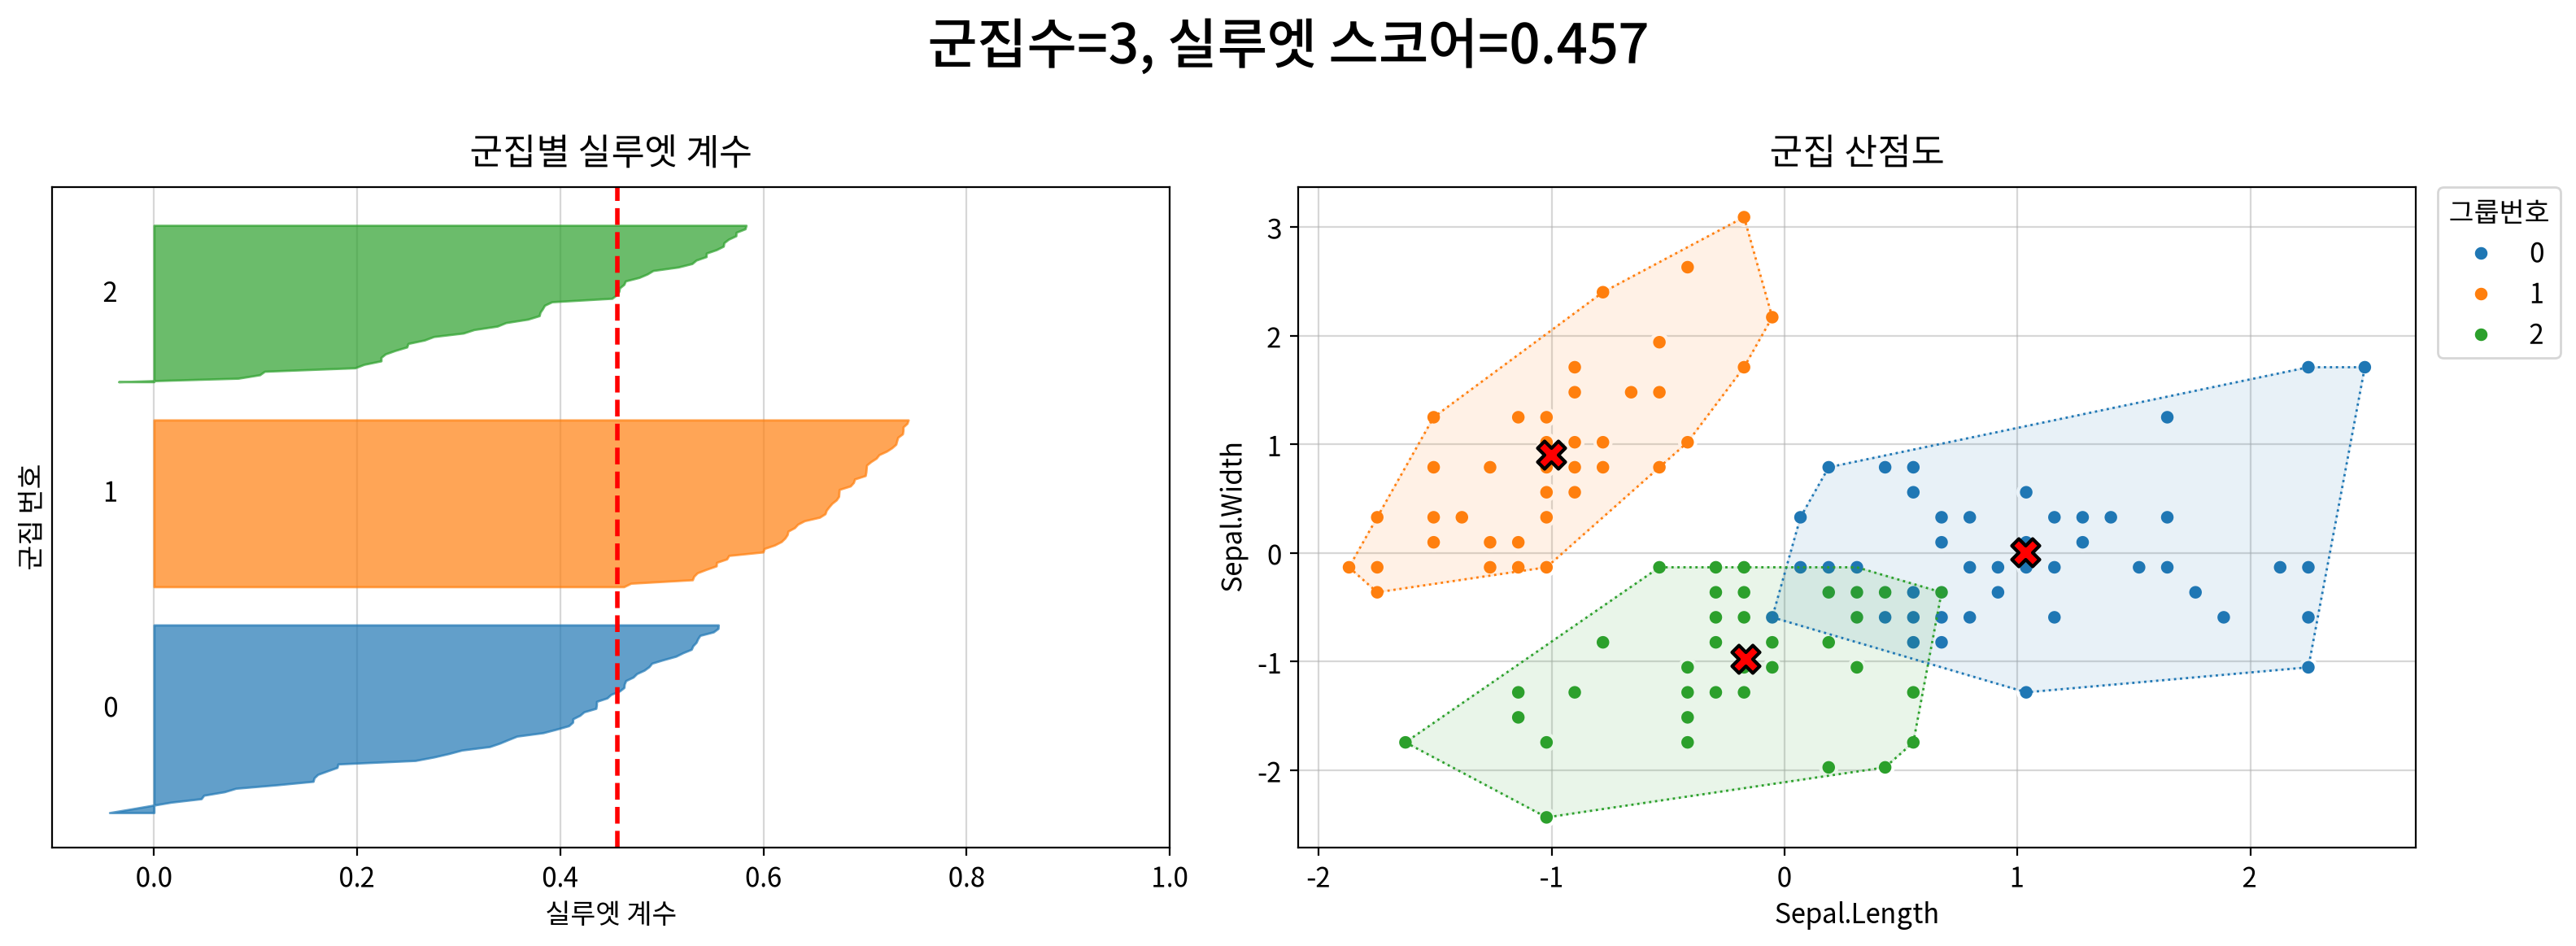

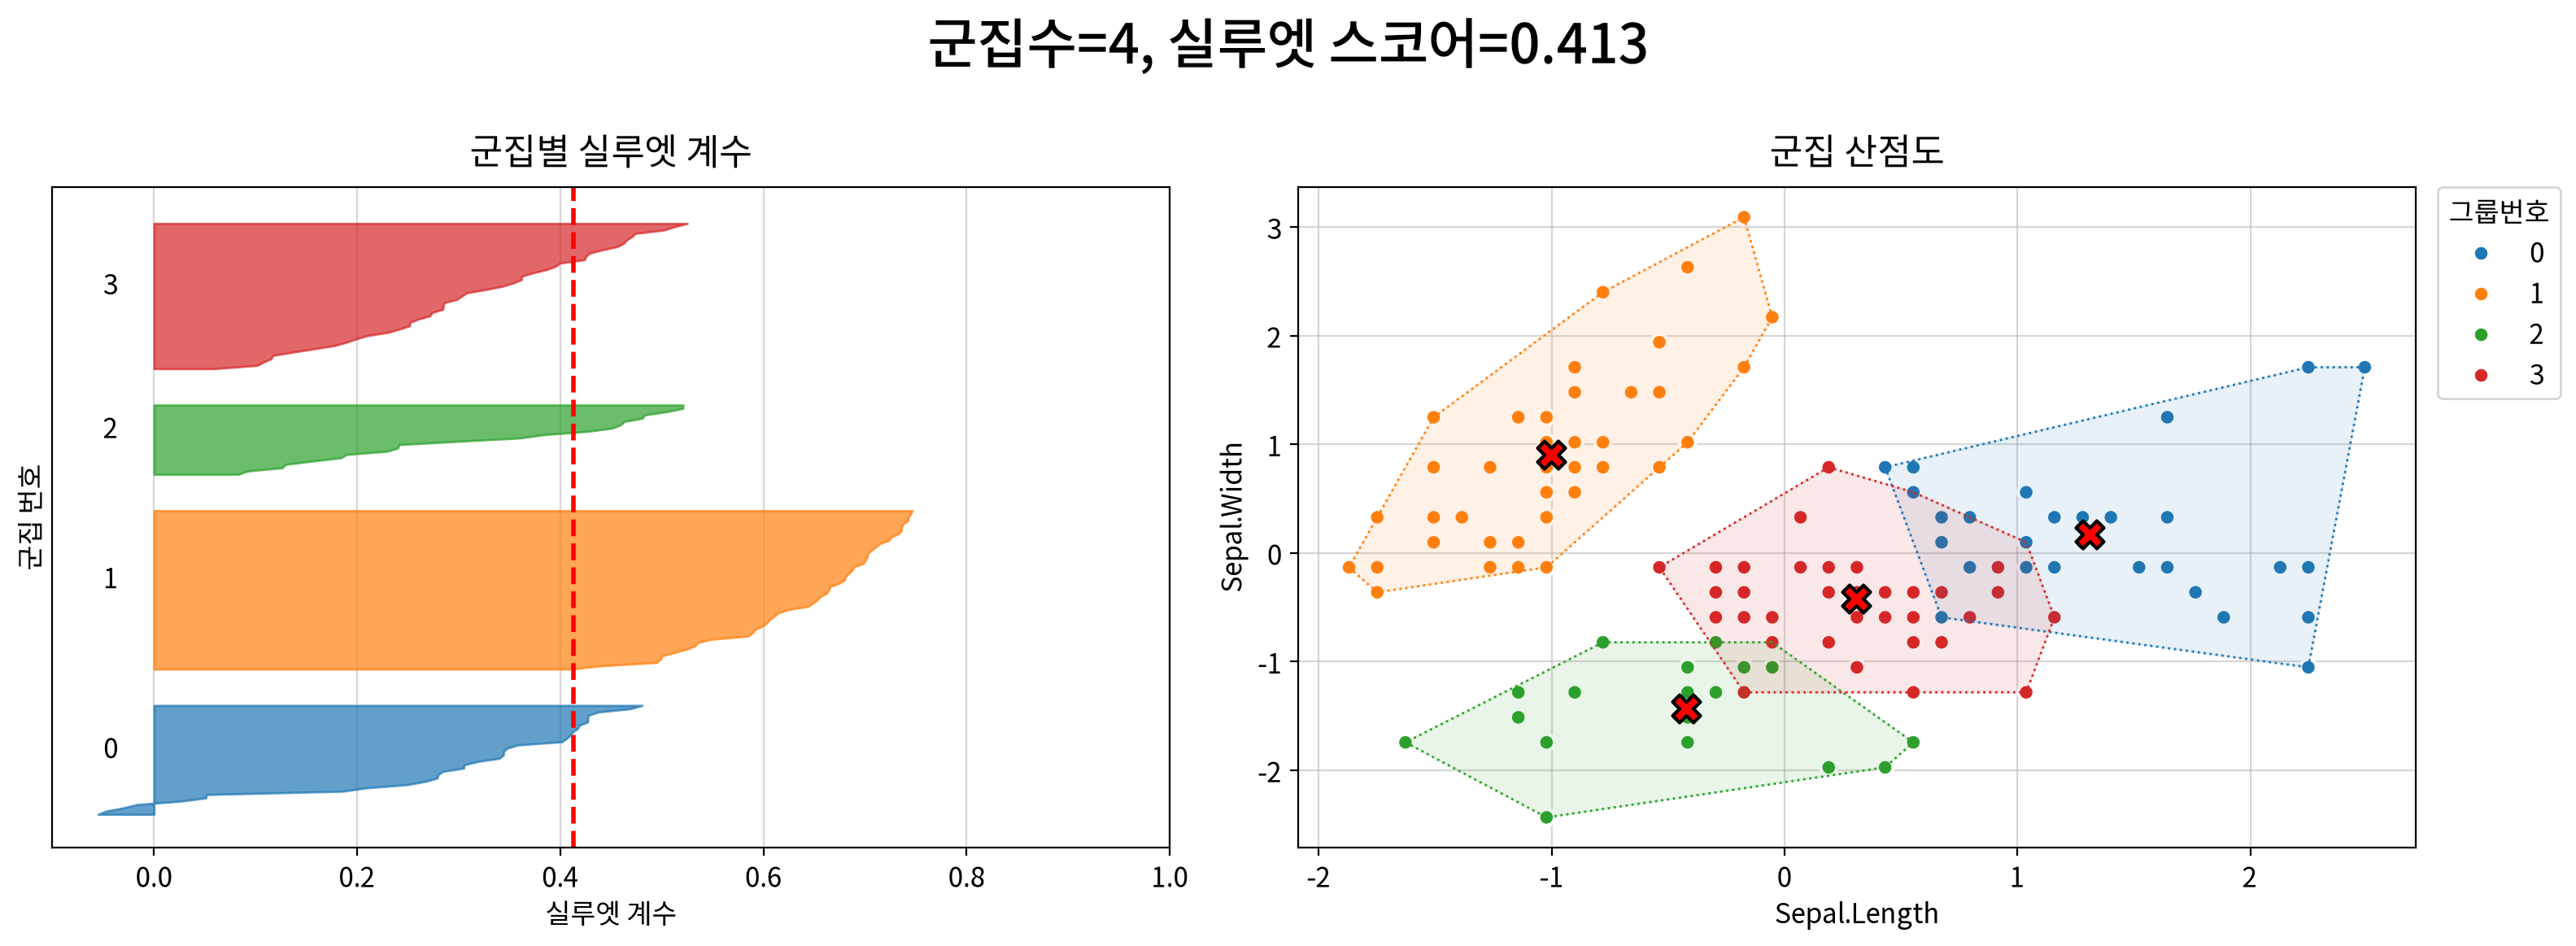

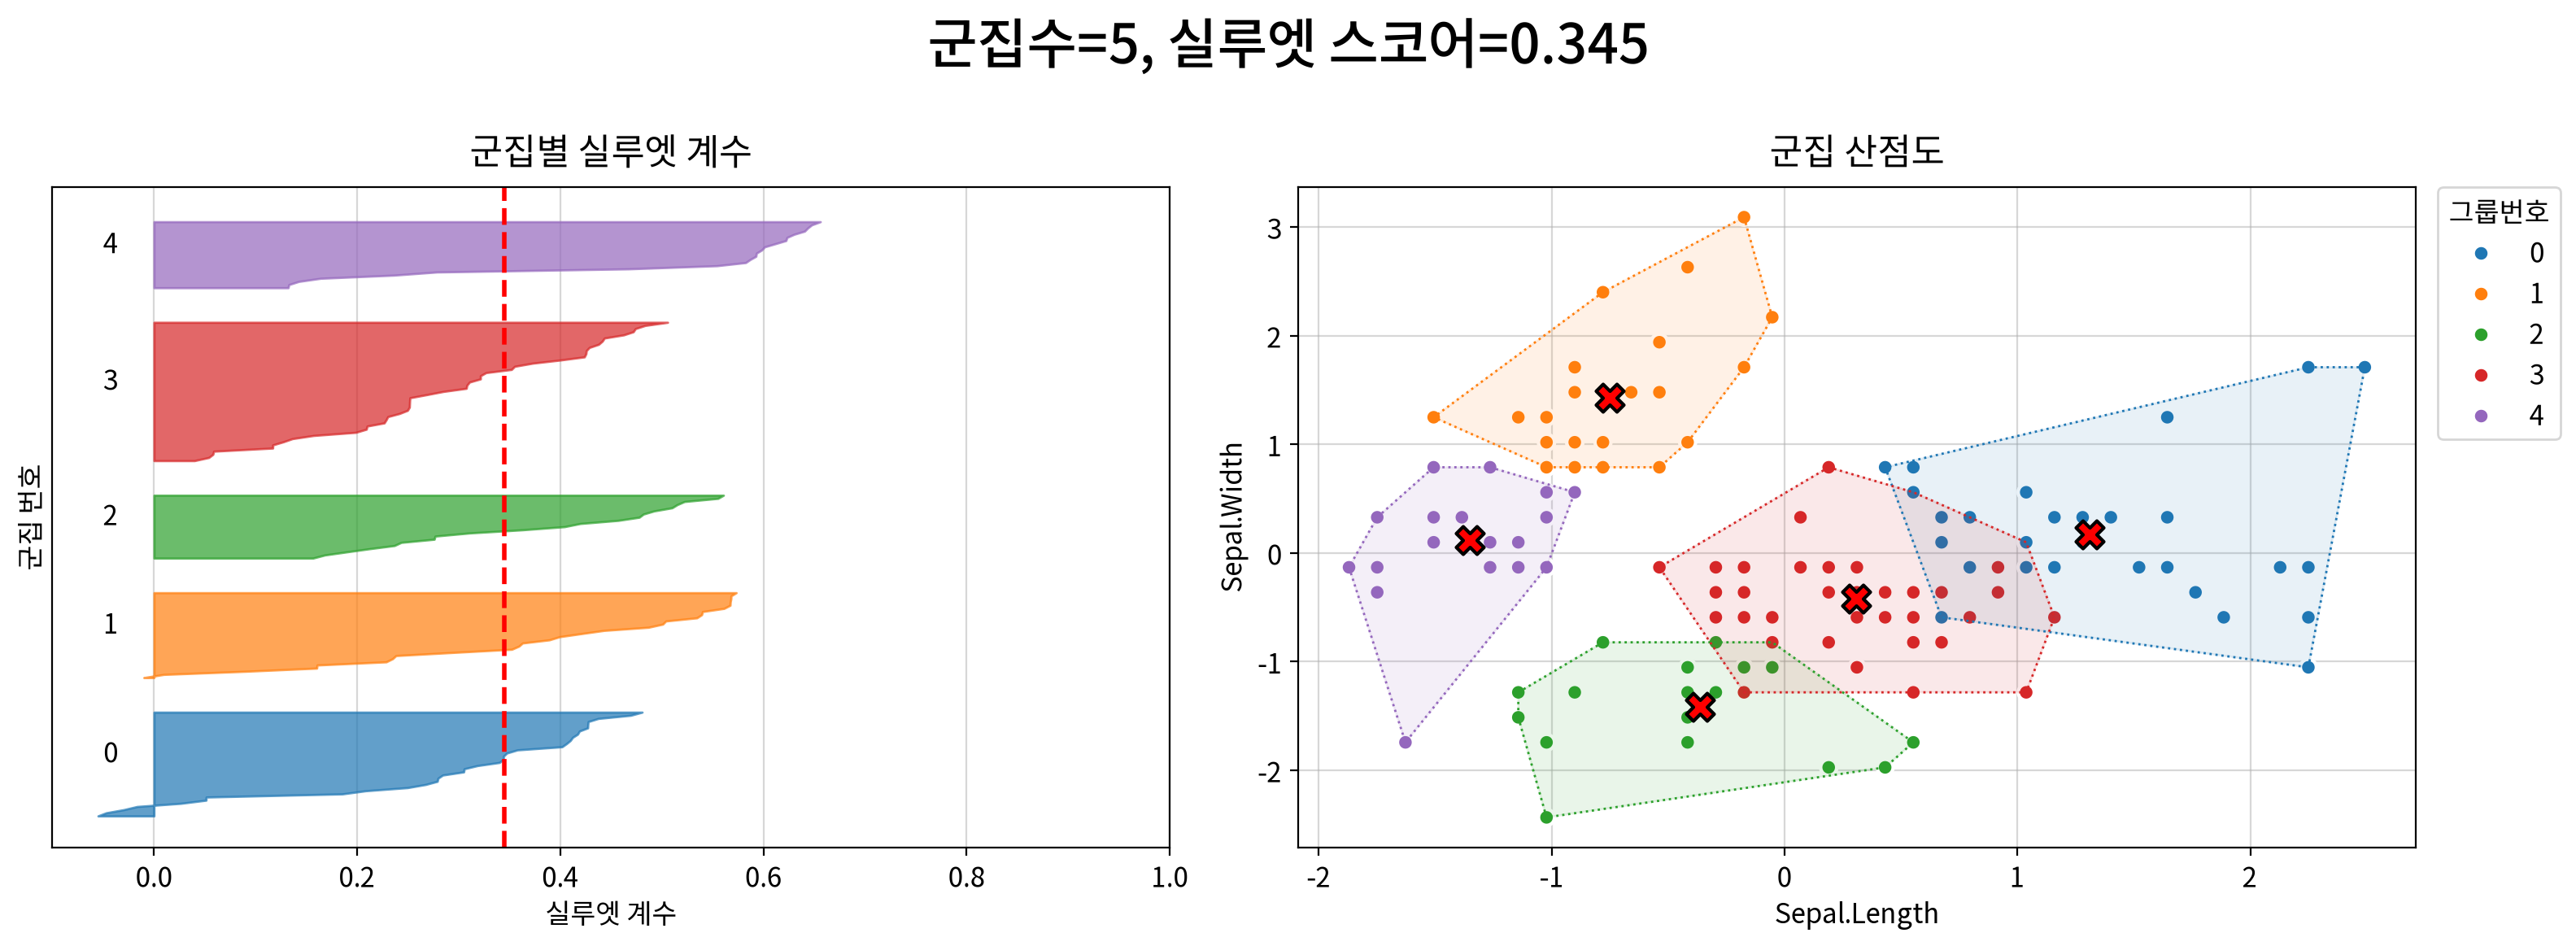

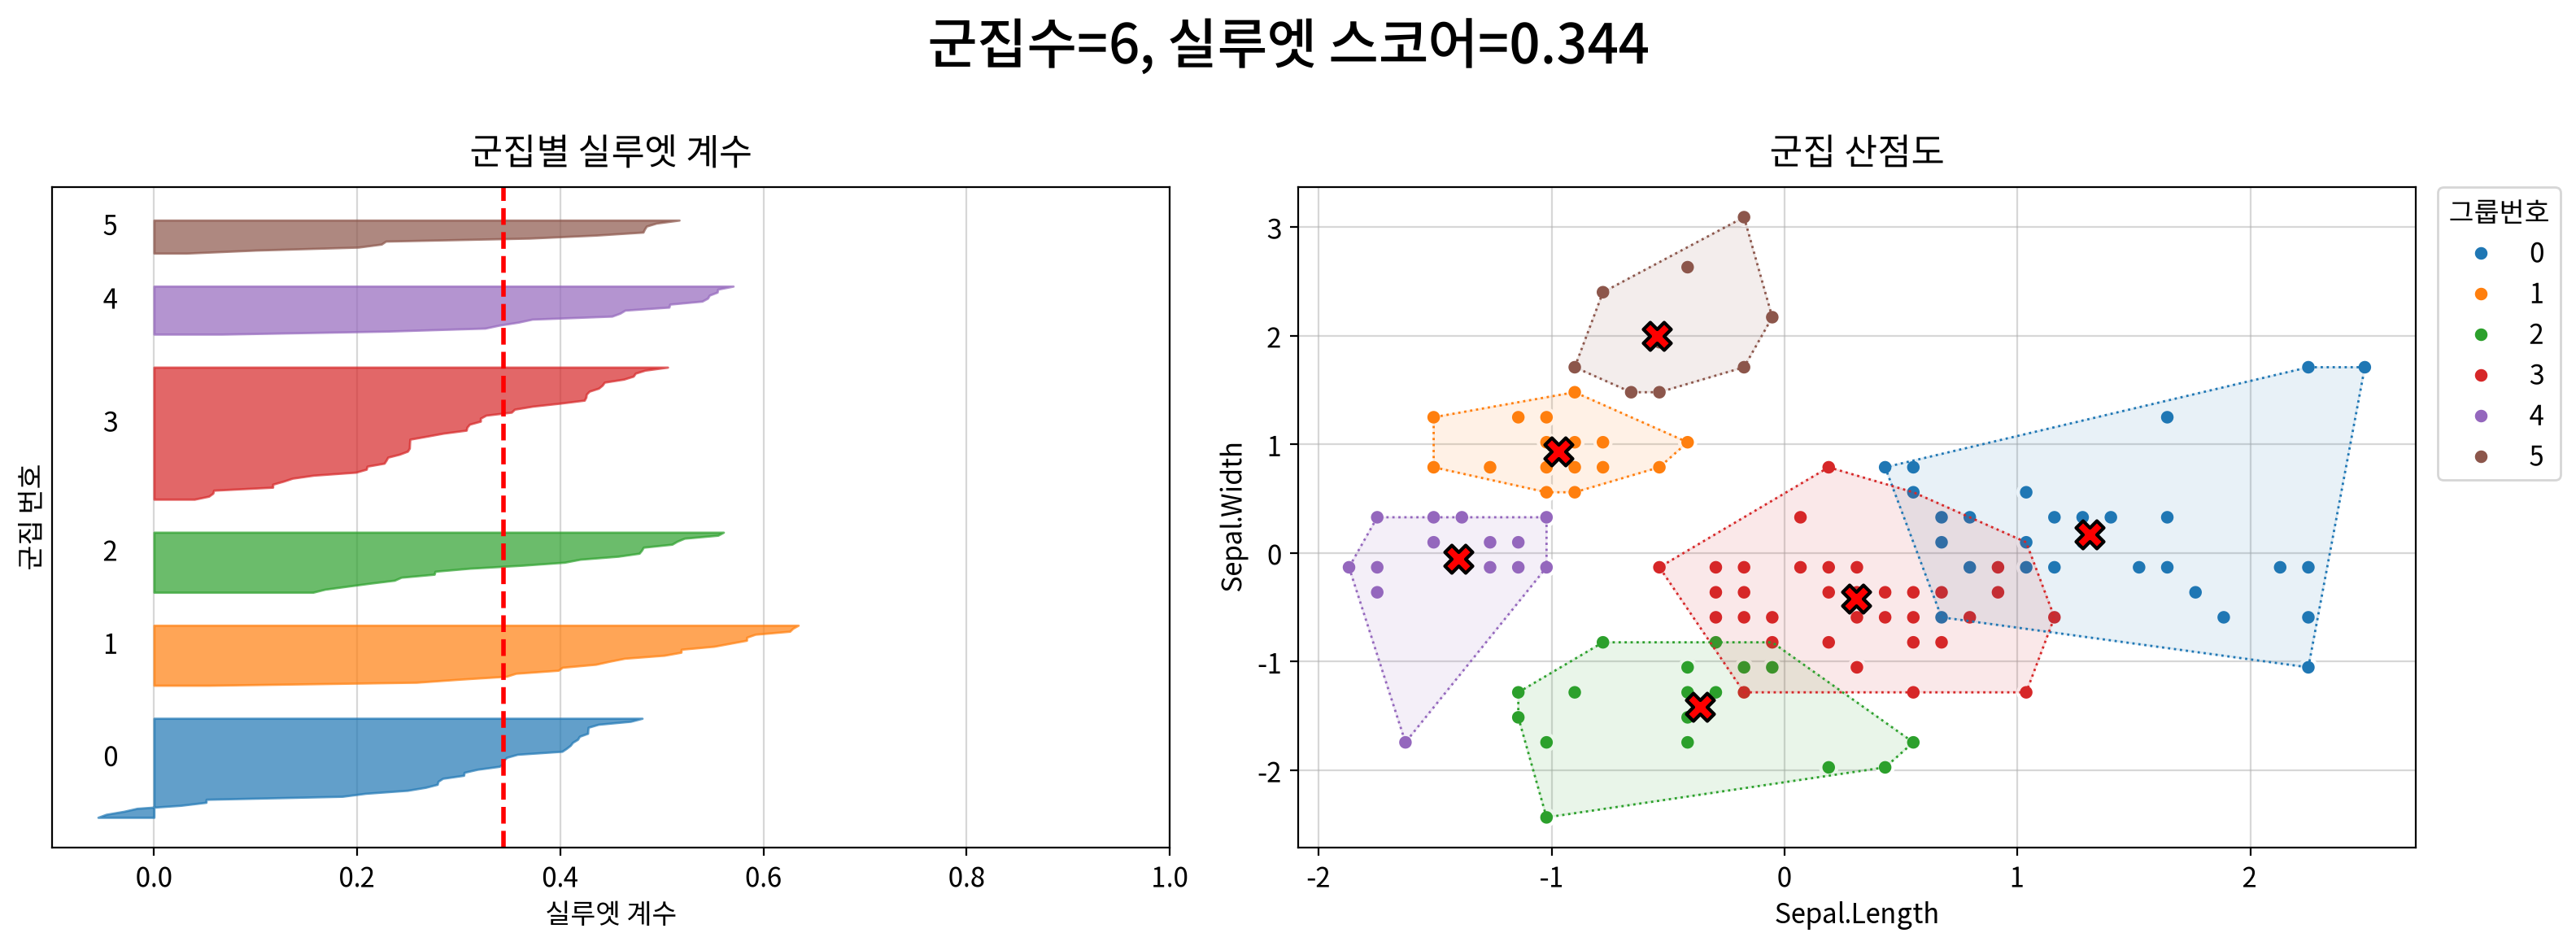

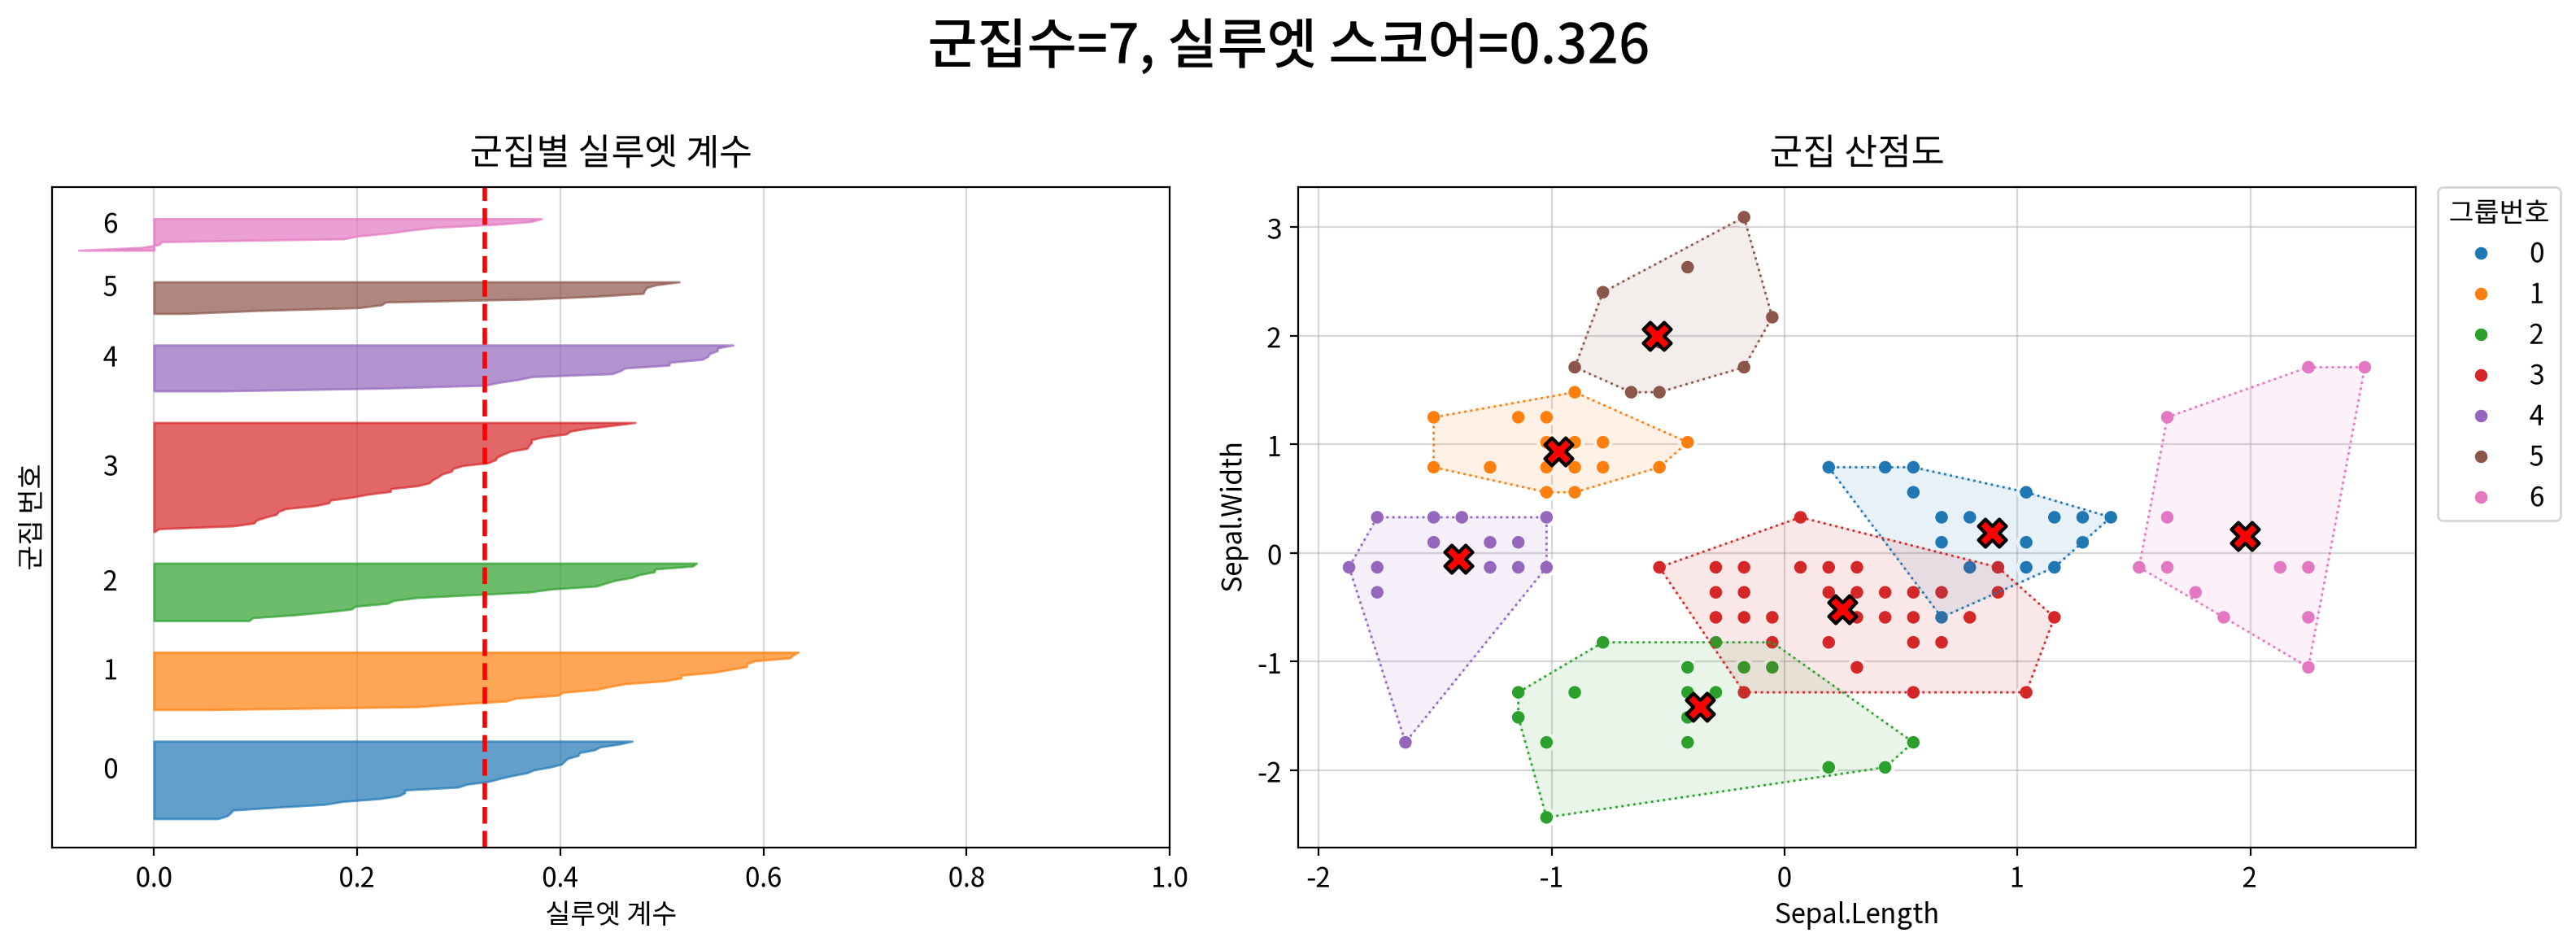

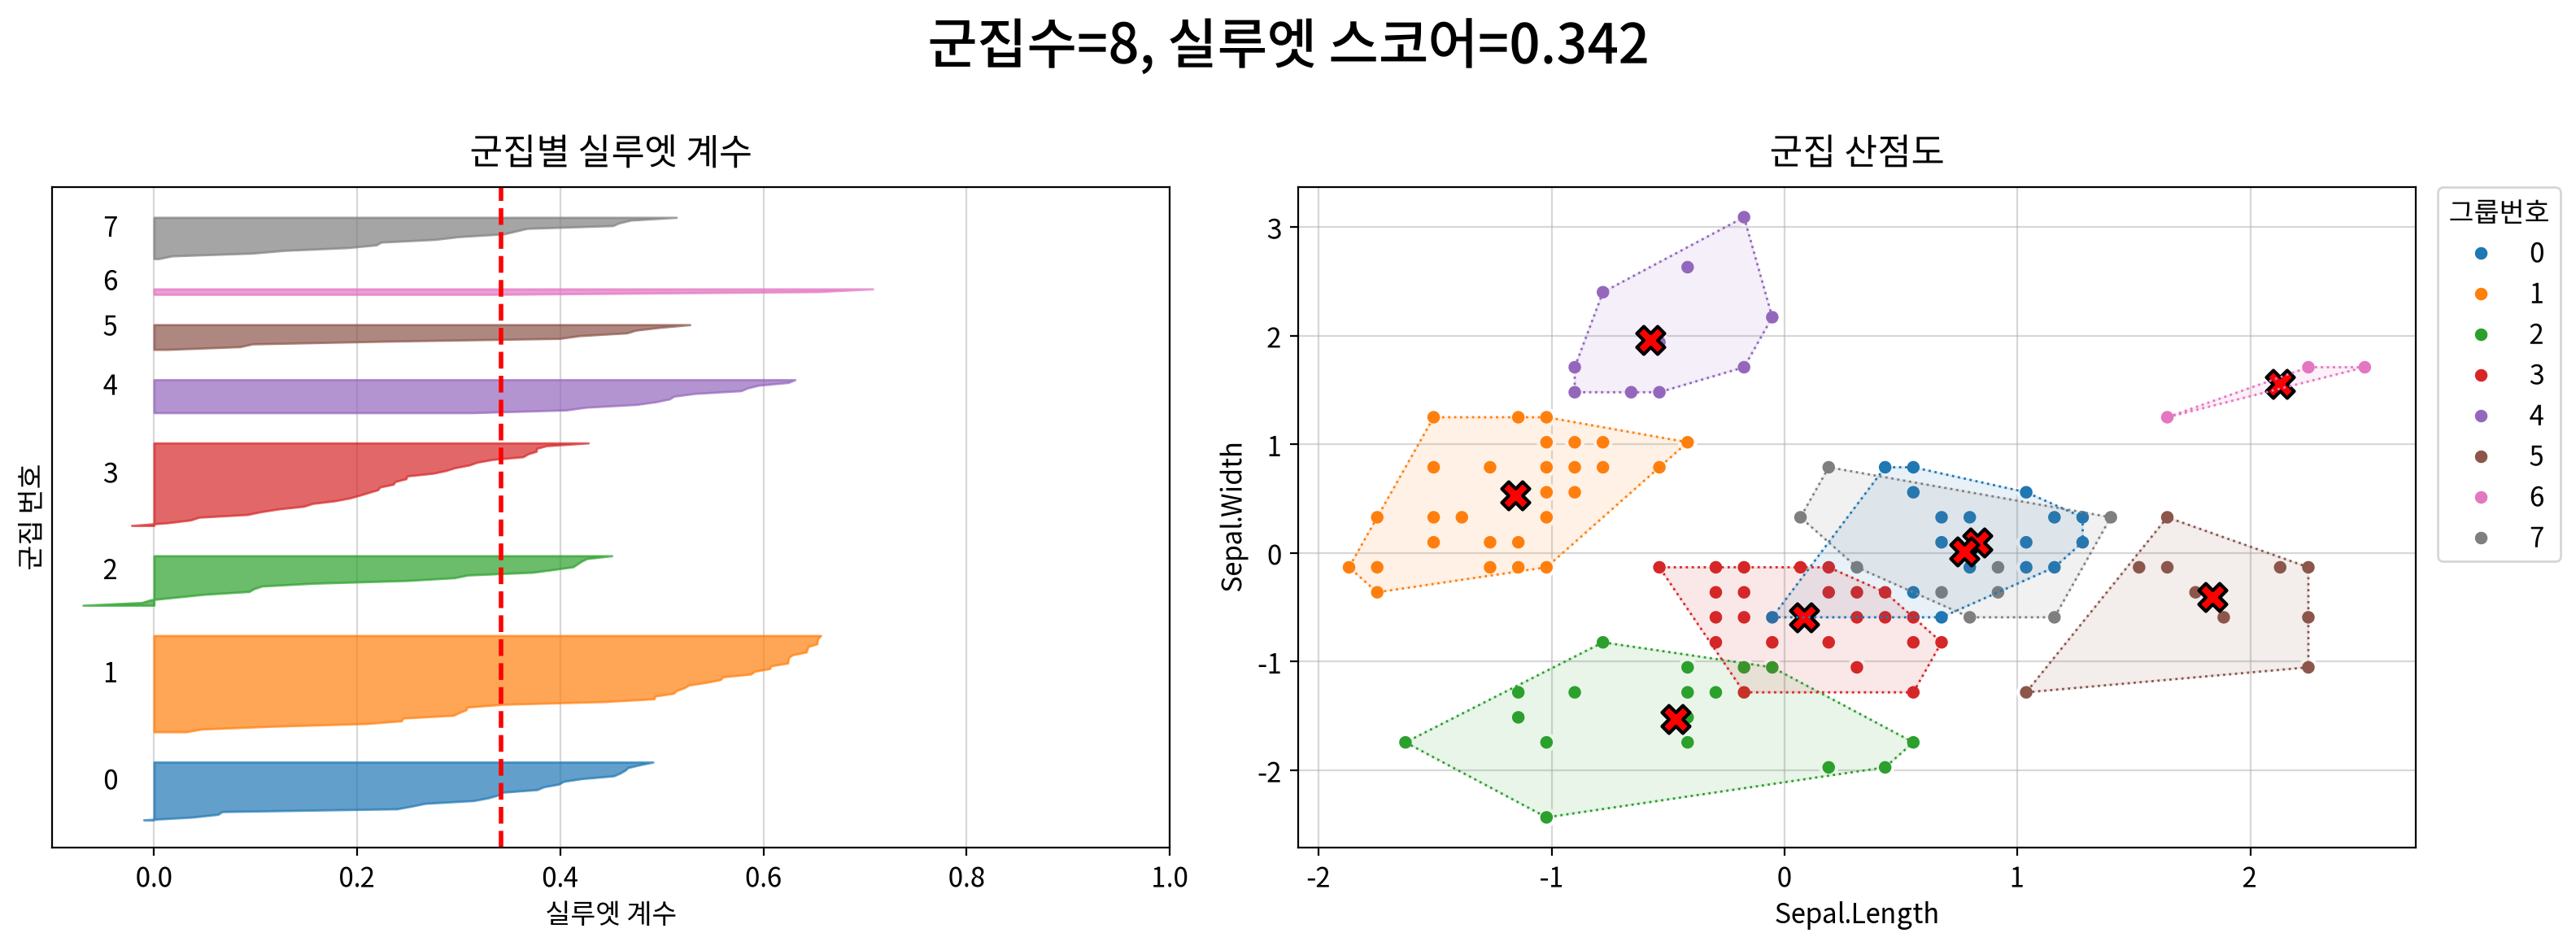

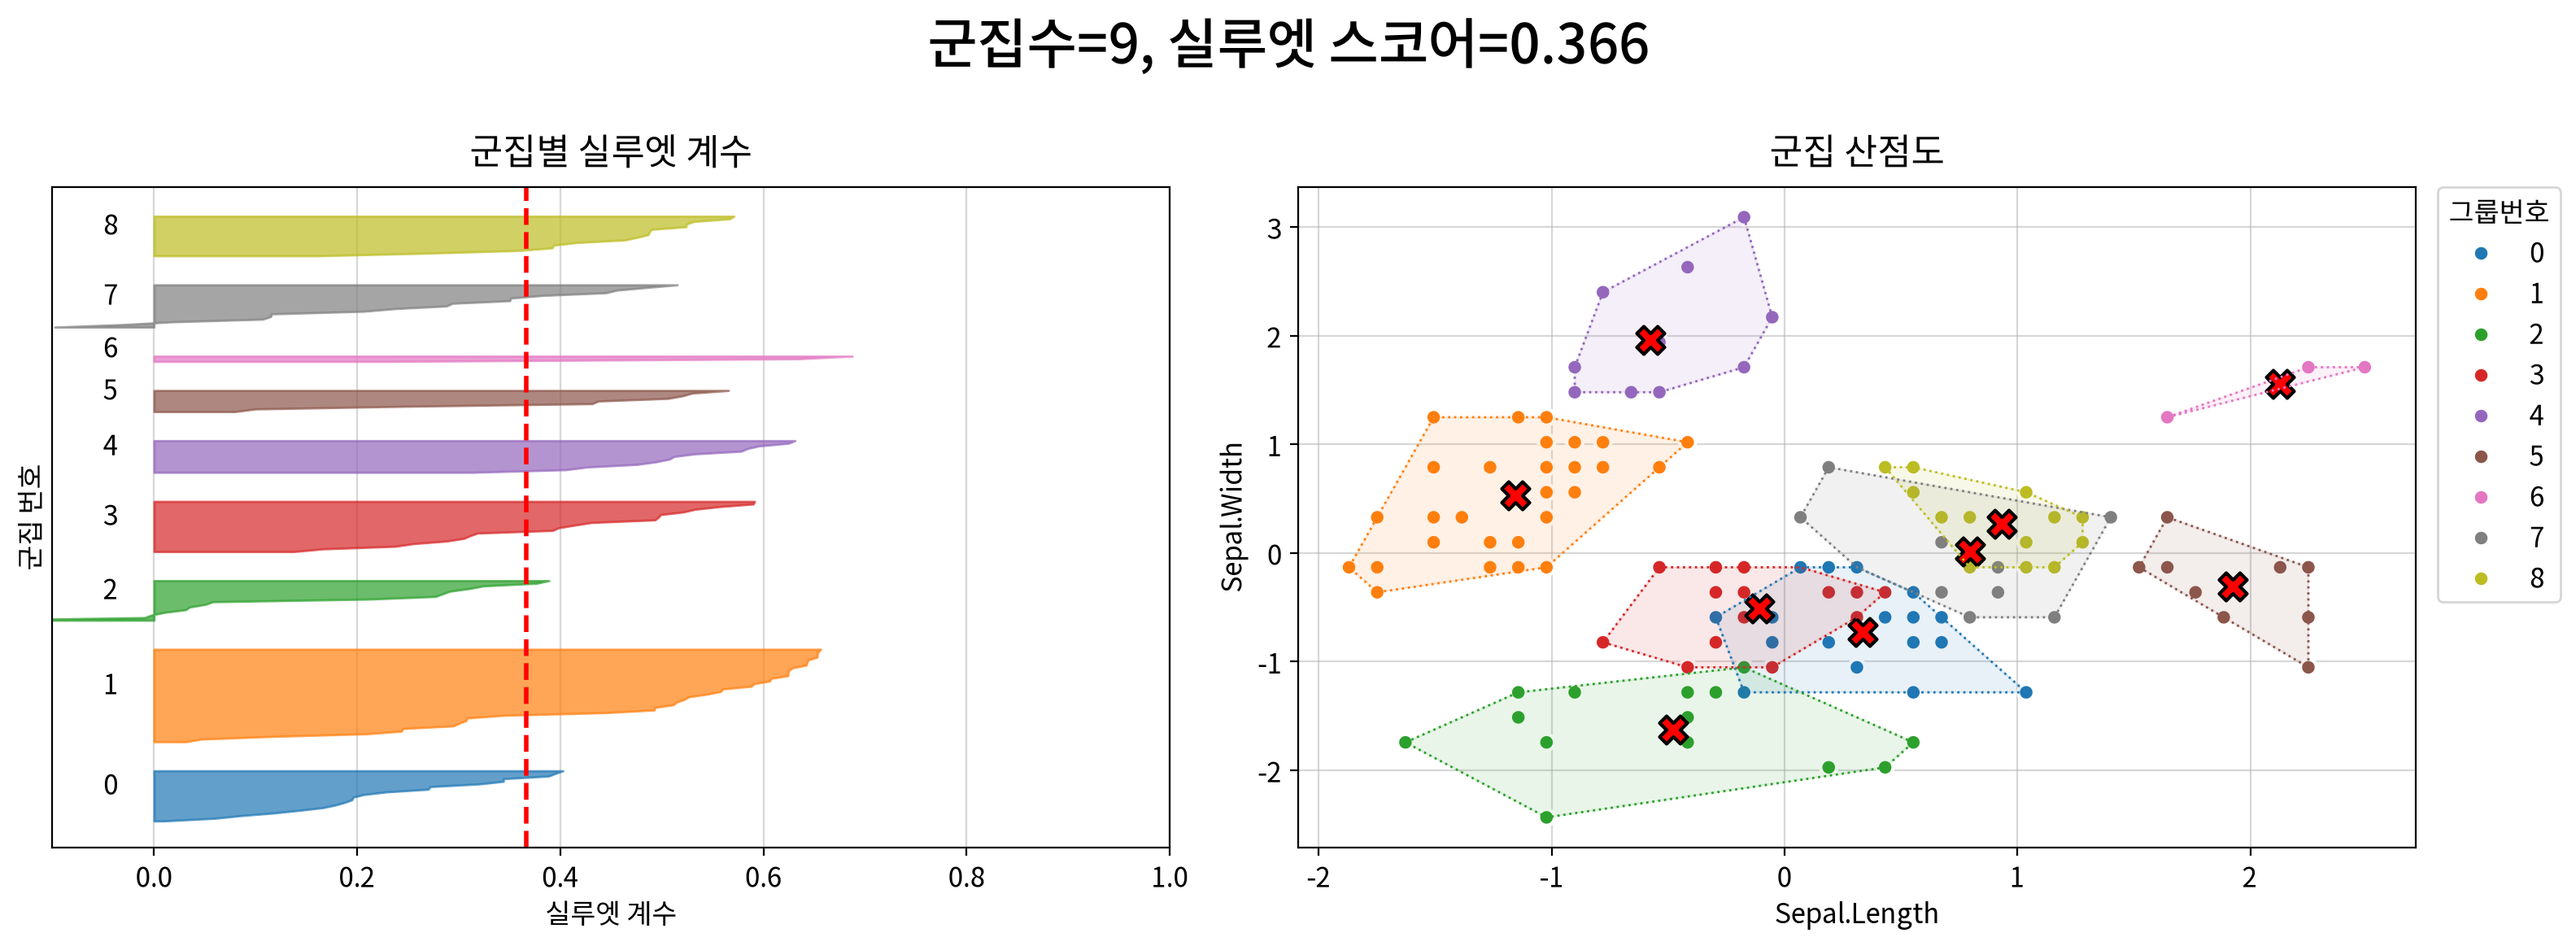

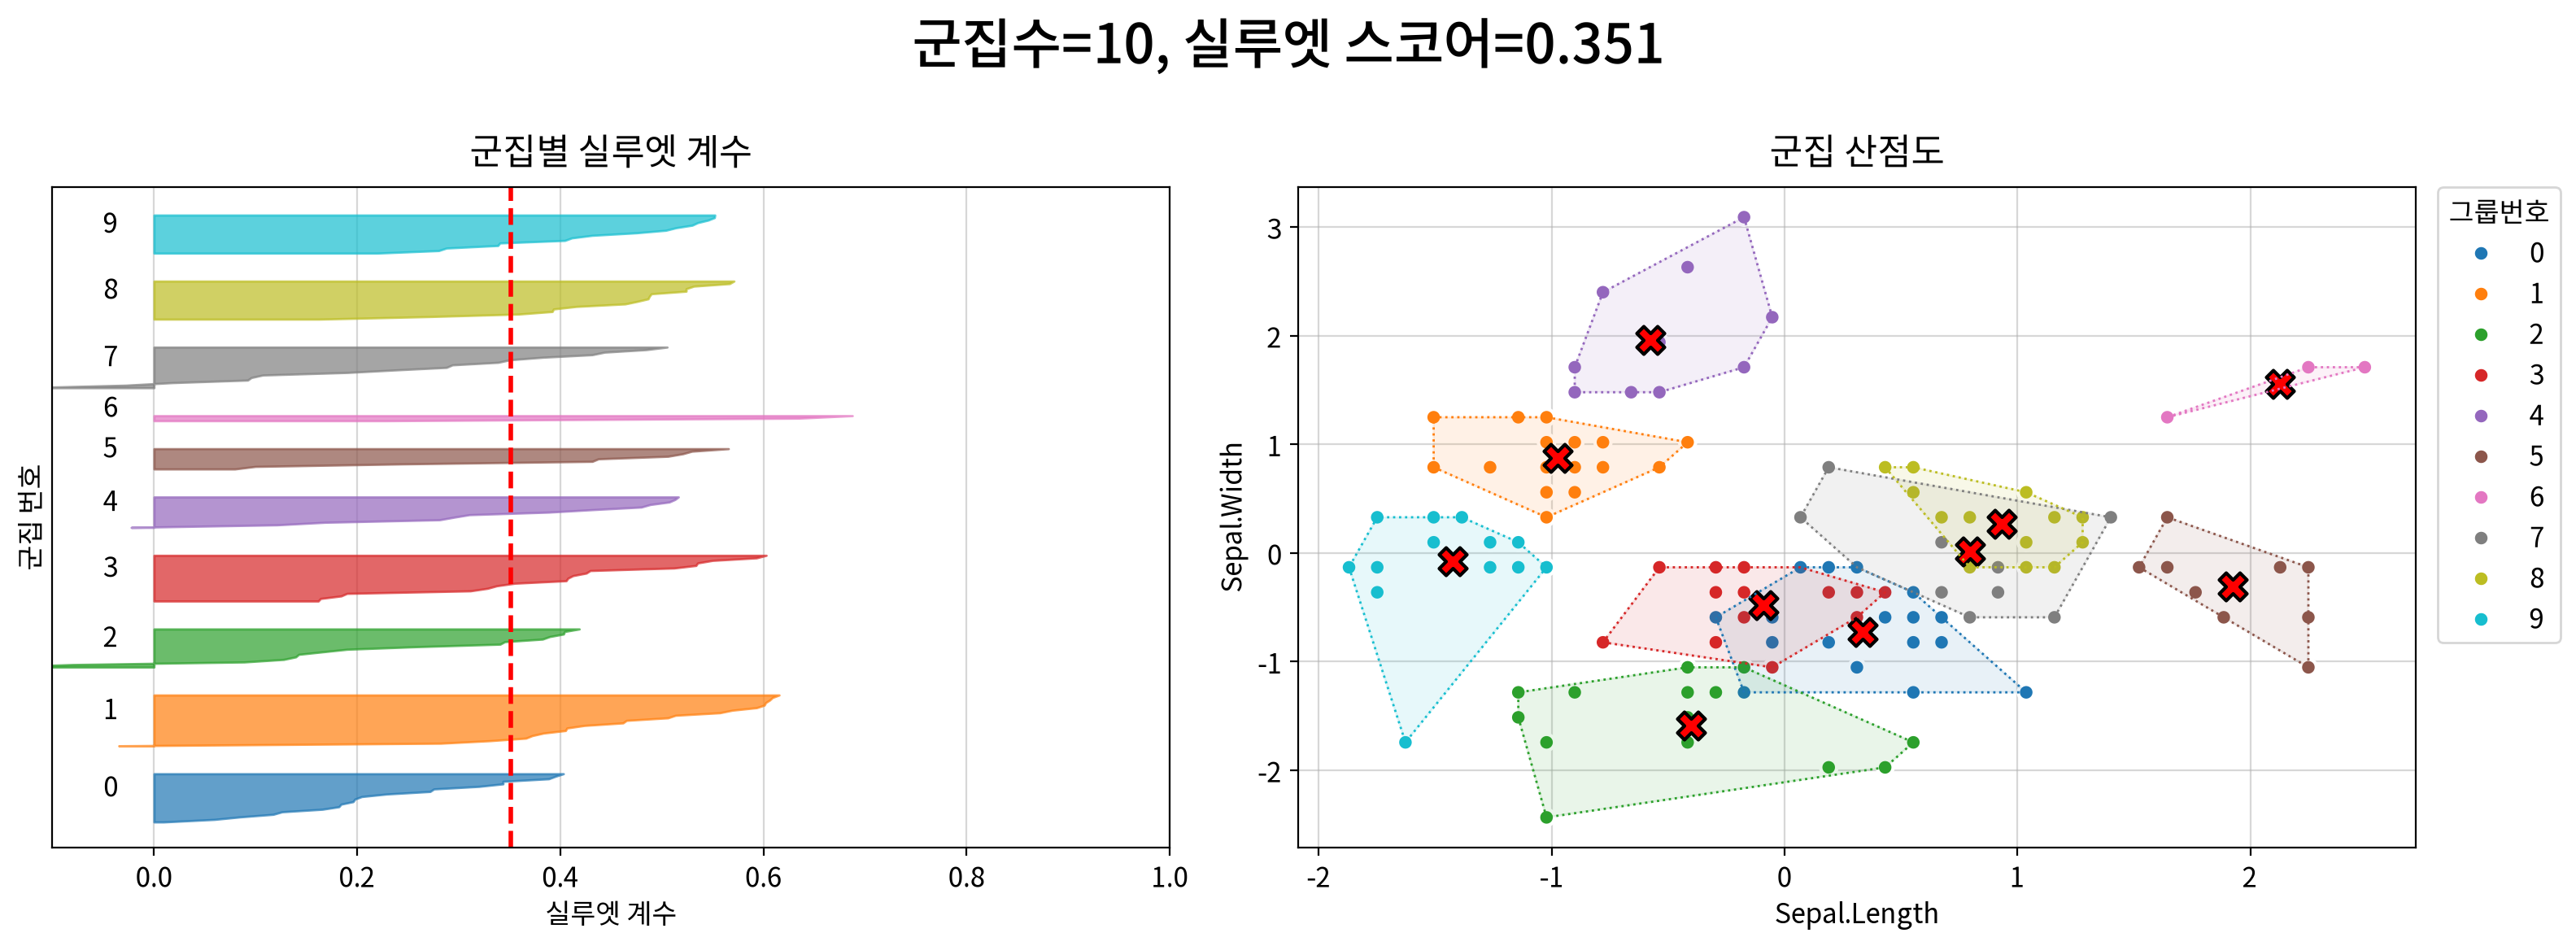

,0,1,2,7,8,3,4,6,5
k,2.000,3.000,4.000,9.000,10.000,5.000,6.000,8.000,7.000
score,0.582,0.457,0.413,0.366,0.351,0.345,0.344,0.342,0.326


In [10]:
s_items = []

for k in klist:
    estimator, _, _ = my_cluster.kmeans(sdf, k=k, scaling=None,
                                        plot=False, verbose=False)
    cluster = estimator.labels_

    my_cluster.visualize_silhouette(estimator, sdf)    # 실루엣 시각화
    s_score = silhouette_score(X=sdf, labels=cluster)  # 실루엣 스코어

    s_items.append({"k": k, "score": round(s_score, 4)})

score_df = DataFrame(s_items).sort_values(by="score", ascending=False)
score_df.T

### 4. 막대의 **면적**으로 K 고르기

In [11]:
area_items = []

for k in klist:
    estimator, _, _ = my_cluster.kmeans(sdf, k=k, scaling=None, plot=False, verbose=False)
    cluster = estimator.labels_

    # 데이터 하나하나의 실루엣 계수 (= 얇은 띠 하나의 가로 길이)
    s_samples = silhouette_samples(X=sdf, labels=cluster)

    # 군집별 면적(계수의 합)과 두께(데이터 개수)
    area = np.array([s_samples[cluster == c].sum() for c in range(k)])
    size = np.array([(cluster == c).sum() for c in range(k)])

    area_items.append({
        "k": k,
        "스코어": round(s_samples.mean(), 3),      # 계수의 평균 = 실루엣 스코어
        "전체면적": round(area.sum(), 1),           # 계수의 합 = 150 × 스코어
        "두께비": round(size.max() / size.min(), 2),
        "최소상대면적": round(area.min() / area.sum() * k, 2),
    })

area_df = DataFrame(area_items)
area_df

,k,스코어,전체면적,두께비,최소상대면적
0,2,0.582,87.300,2.000,0.780
1,3,0.457,68.500,1.200,0.770
2,4,0.413,62.000,2.230,0.450
3,5,0.345,51.800,2.140,0.760
4,6,0.344,51.600,3.750,0.470
5,7,0.326,48.800,3.250,0.310
6,8,0.342,51.300,12.000,0.260
7,9,0.366,54.900,12.000,0.250
8,10,0.351,52.700,7.000,0.290


#### 인사이트 — 최종 k 선정

지금까지 나온 답을 모으면 이렇다.

| 지표 | 추천 K | 근거 | 판정 |
|---|---|---|
| 엘보우 (#03) | 5 | 이너셔 감소폭이 꺾이는 지점 | ❌ 엘보우 후보이지만 면적이 `51.3` · `48.9` 로 K = 3 (`69.0`)의 **71~74% 수준**까지 줄고,<br/>스코어도 `0.342` · `0.326` 으로 K = 3 (`0.460`)보다 크게 낮다 |
| 실루엣 **스코어** | 2 | 평균 점수가 가장 높다 (0.582) | ❌ 스코어는 1위지만 막대가 `100 : 50` 으로 두께비 2.00 이고,<br/>두꺼운 쪽의 평균 계수 `0.532` 가 전체 평균선 `0.582` 에 미달한다 → **아직 덜 쪼갠 상태** |
| 실루엣 **면적** | **3** | 면적을 크게 잃지 않으면서 두께가 가장 고르다 | ⭕ 면적 `69.0`(2위) + 두께비 `1.13`(**1위**) + 최소상대면적 `0.71`.<br/>K를 더 늘리면 세 지표가 **동시에** 나빠진다 |

> ⚠️ K = 3 의 실루엣 스코어 `0.460` 은 앞에서 말한 기준 `0.5` 에 못 미친다.
> `iris` 의 두 품종이 실제로 겹쳐 있기 때문이며, 이 데이터에서 `0.5` 를 넘기려면 K = 2 로 되돌아가는 수밖에 없다.
> 그런데 K = 2 는 방금 **두께 불균형**으로 걸러낸 후보다.
> **점수 기준을 기계적으로 적용하지 않는 이유**가 여기에 있다.

> **결론: K = 3 으로 확정한다.**
>
> 군집분석은 정답을 맞히는 것이 목적이 아니라 **설명 가능한 구조를 찾는 것**이 목적이다.
> 지표는 후보를 좁혀줄 뿐이고, 마지막 한 걸음은 분석가의 판단이다.


## #04. Best-K에 따른 군집화

### 1. 원래의 품종 분류와 클러스터링 결과 비교

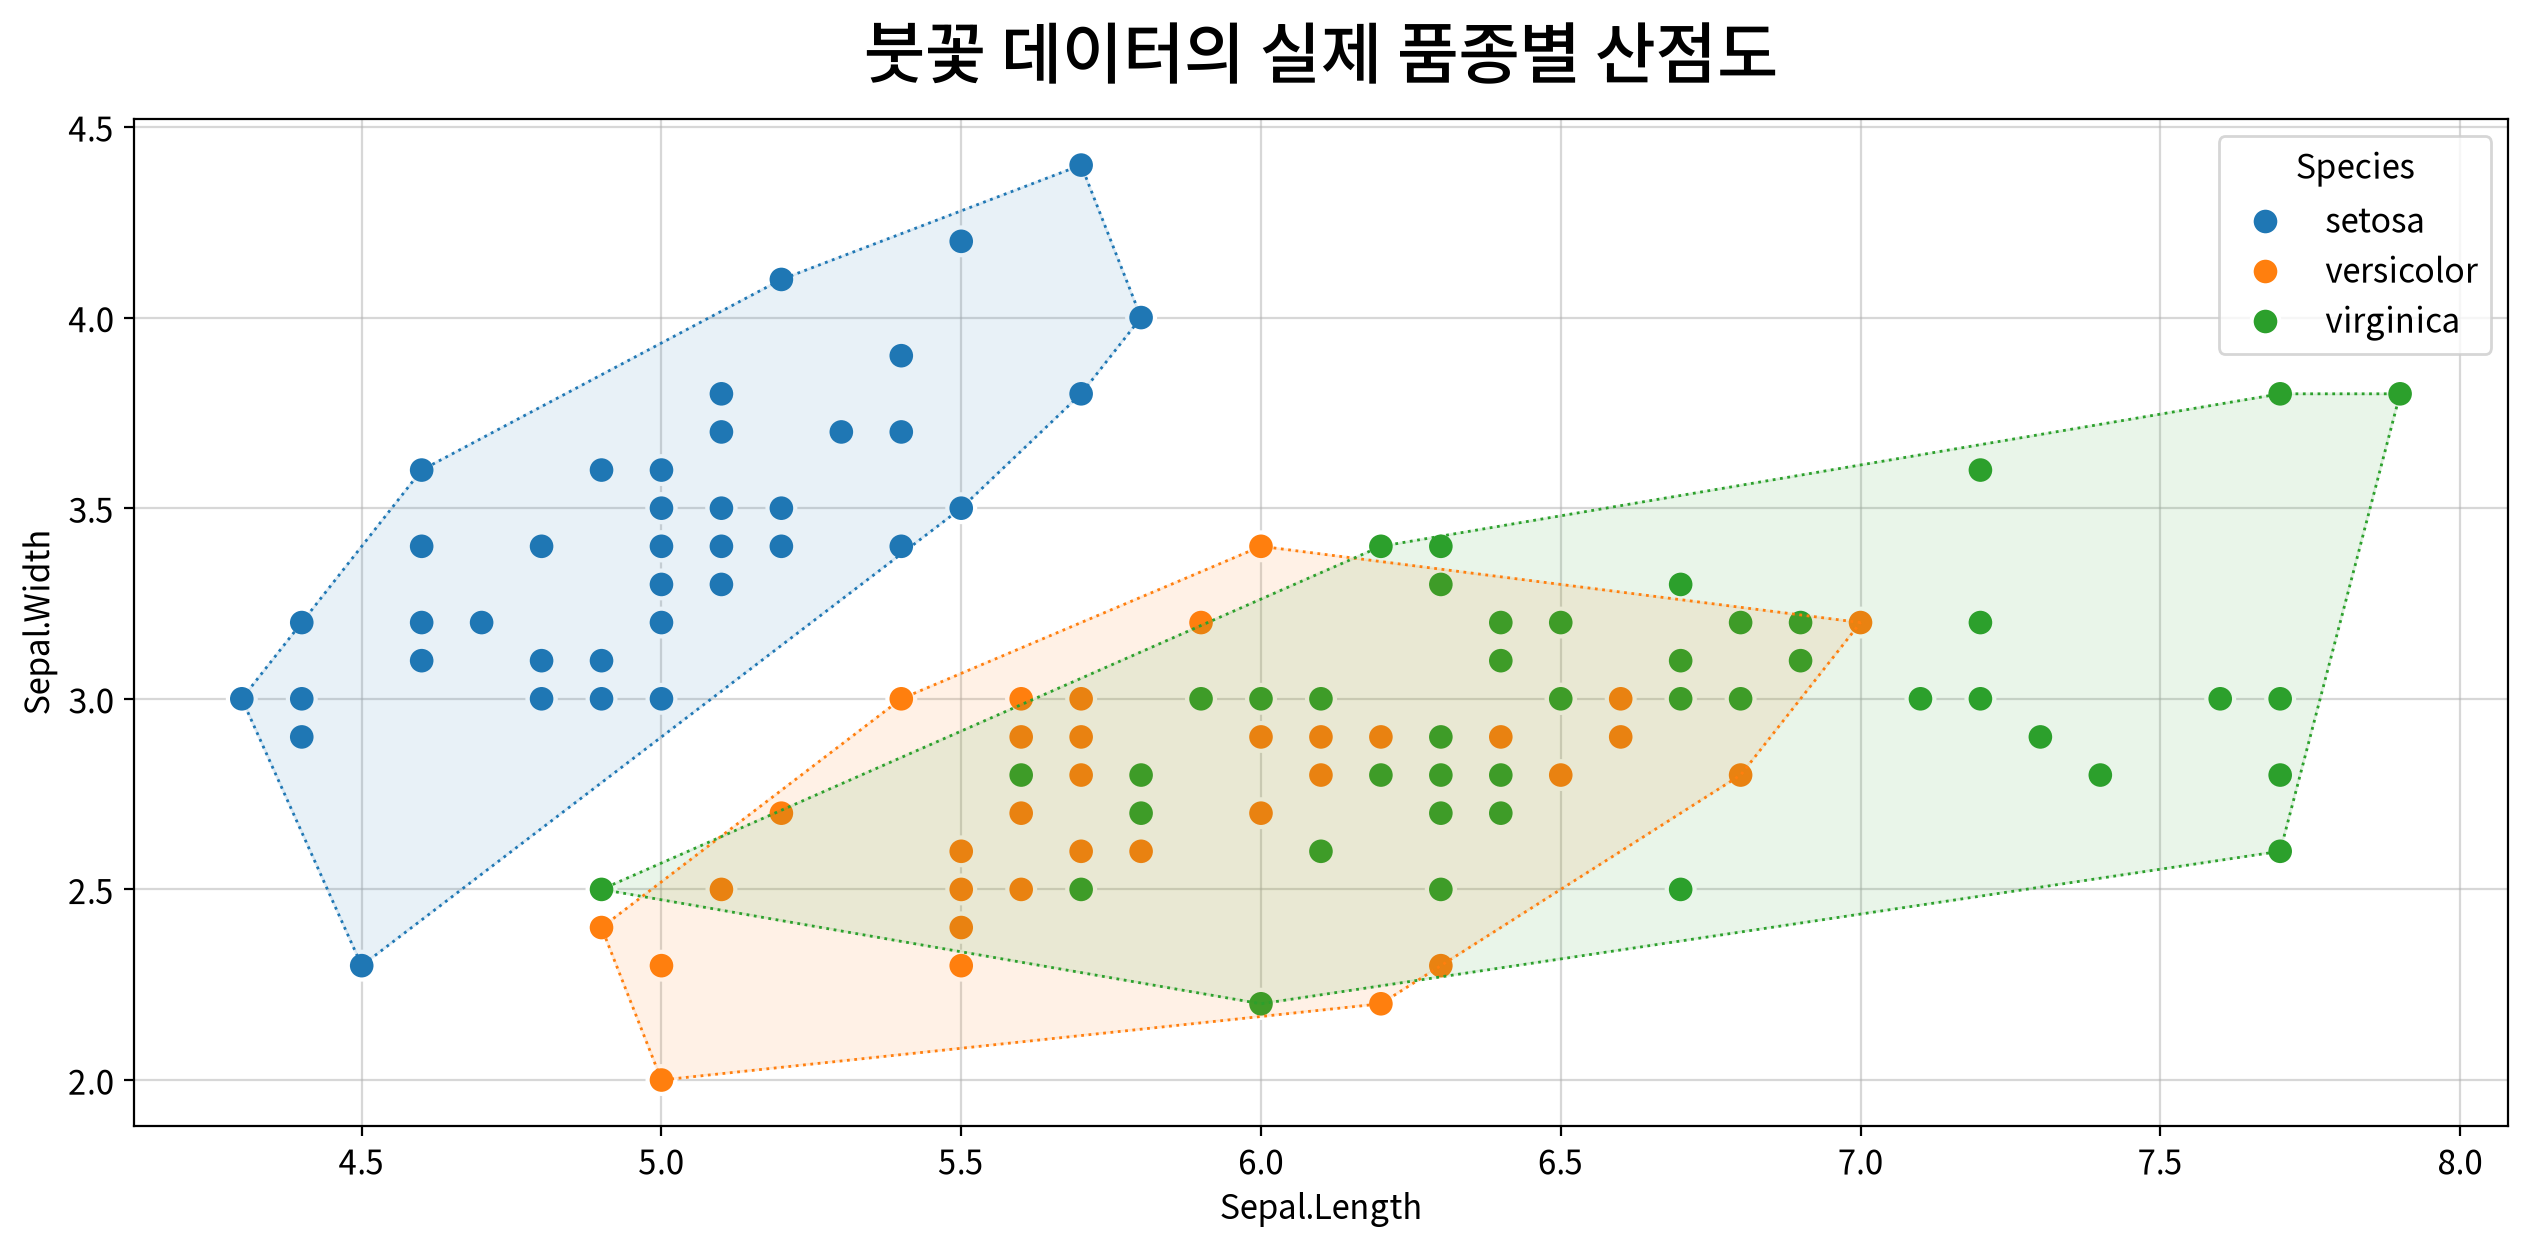

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90          -1.87 ~ 2.49
Sepal.Width          2.00 ~ 4.40          -2.43 ~ 3.09
Petal.Length         1.00 ~ 6.90          -1.57 ~ 1.79
Petal.Width          0.10 ~ 2.50          -1.45 ~ 1.71


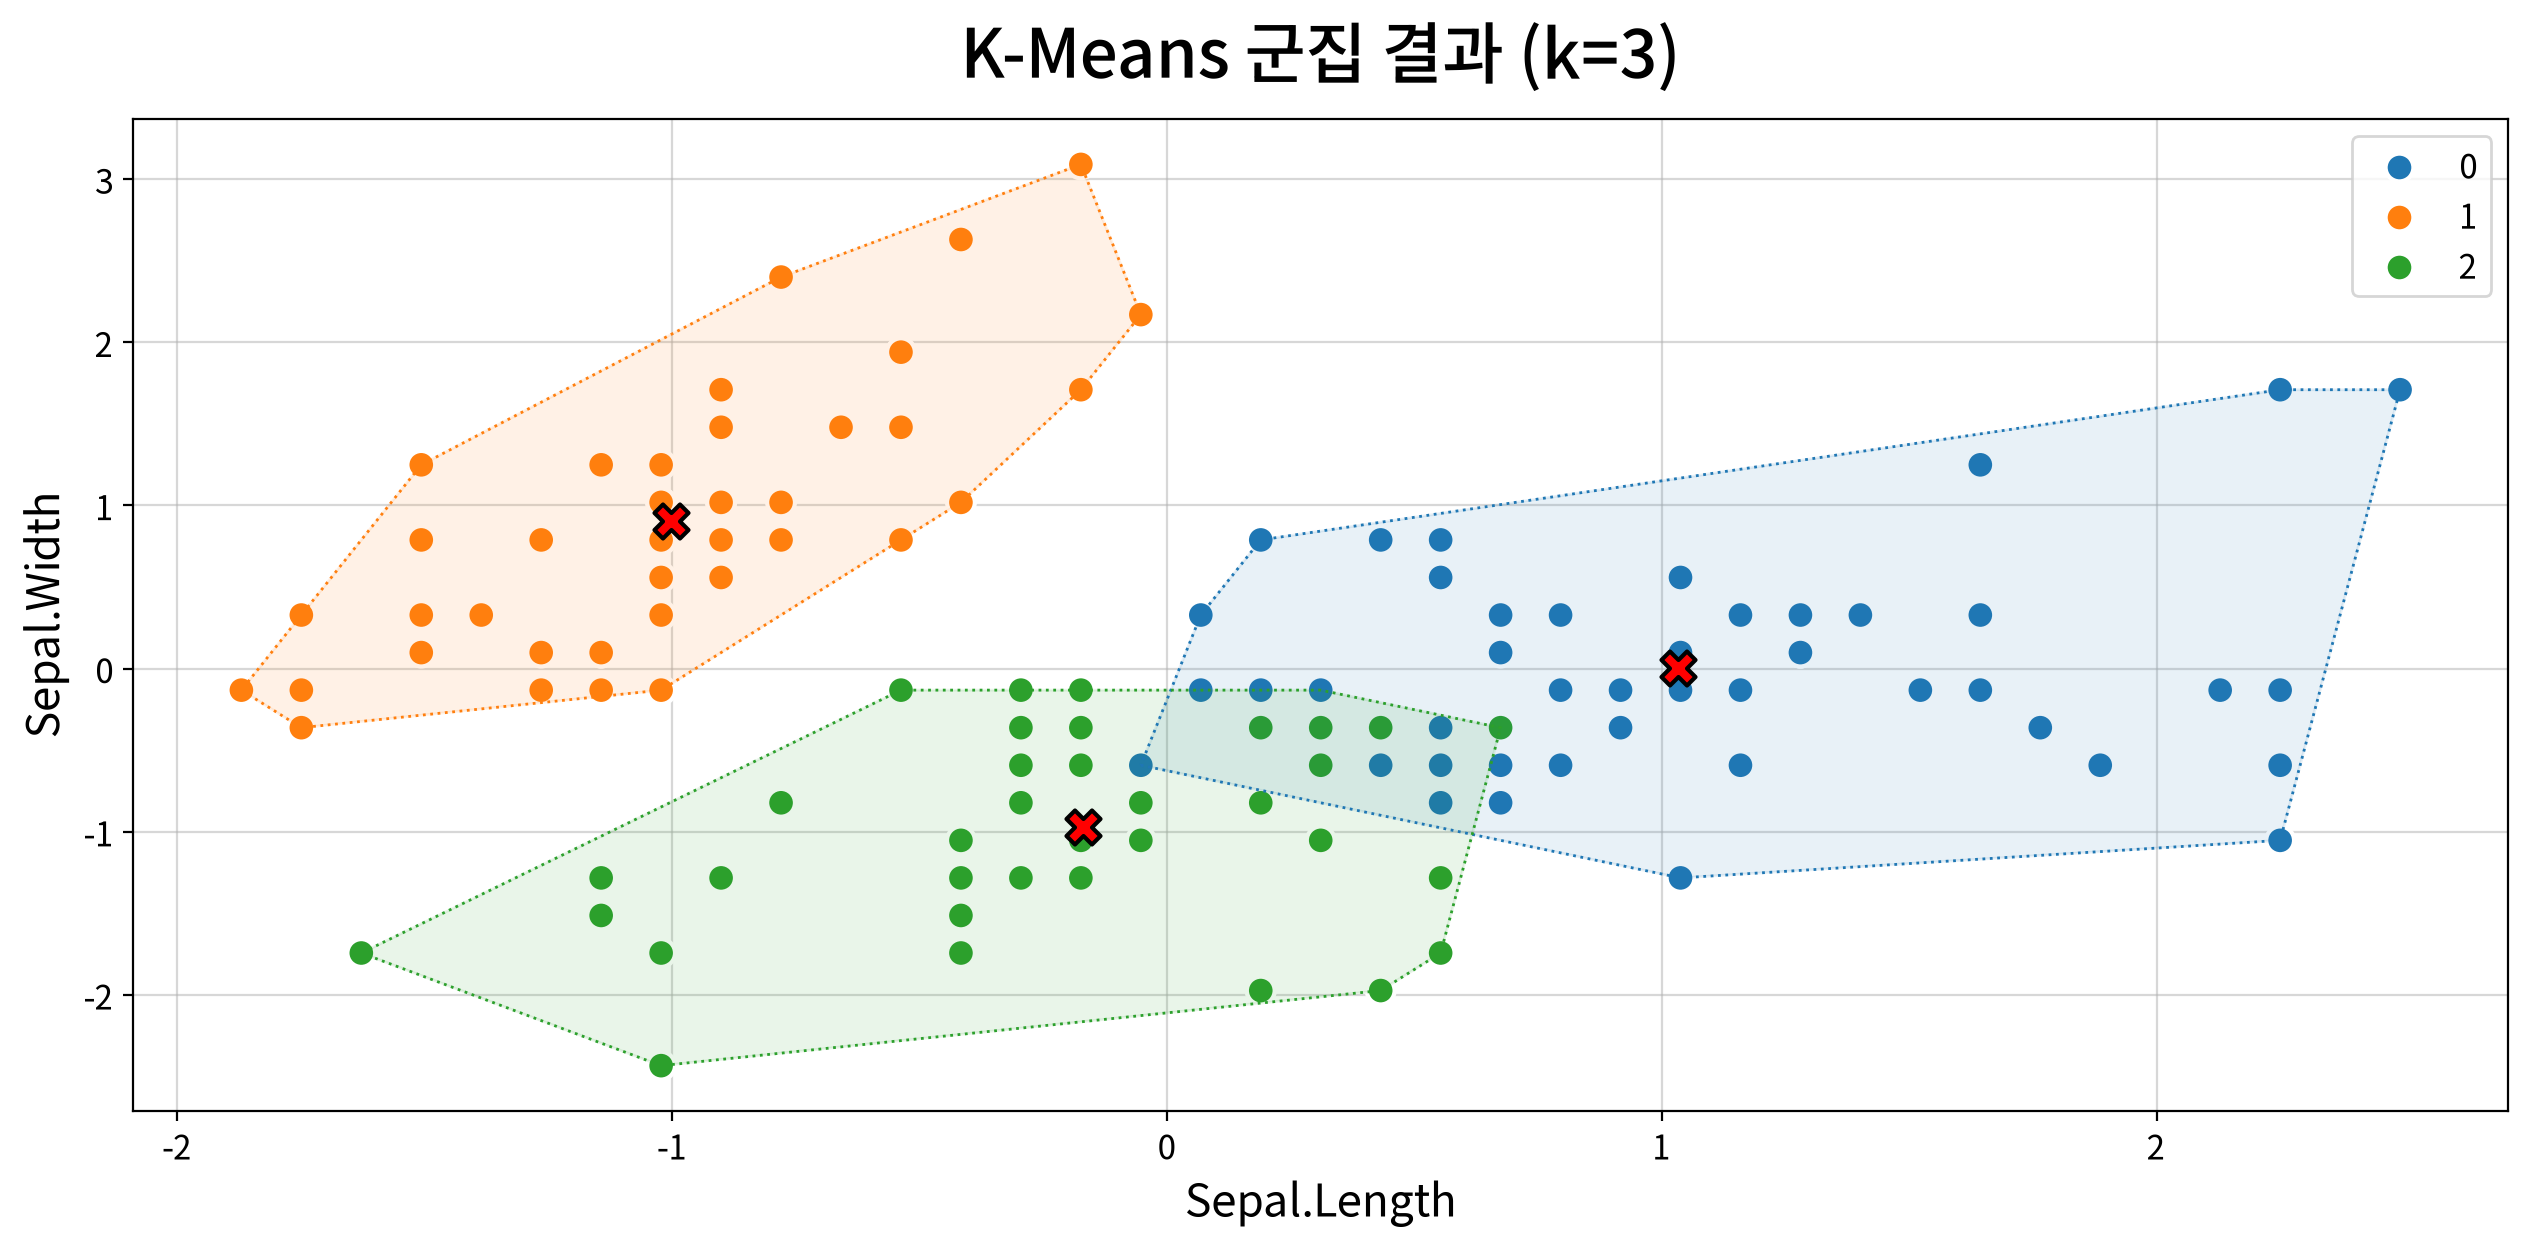

In [12]:
# 원래의 품종별 산점도
my_plot.scatterplot(data=origin, x="Sepal.Length", y="Sepal.Width", hue='Species', title="붓꽃 데이터의 실제 품종별 산점도")

# 클러스터링 
# --> 내부에서 스케일링을 처리하므로 종속변수를 제거한 원본을 전달한다.
estimator, _, _ = my_cluster.kmeans(df, k=3, verbose=True, plot=True)

#### 💡 인사이트

- 한 군집은 특정 품종과 **거의 완벽하게** 일치한다 (setosa — 확실히 떨어져 있던 그 덩어리)
- 나머지 두 군집은 조금씩 섞여 있다 → **versicolor 와 virginica 가 실제로 비슷하게 생겼기 때문**
- 실루엣이 K=2를 선호했던 이유가 바로 이것이다

## #05. 모듈화 기능 확인

### 1. 엘보우 포인트 기반 best-k 찾기

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90          -1.87 ~ 2.49
Sepal.Width          2.00 ~ 4.40          -2.43 ~ 3.09
Petal.Length         1.00 ~ 6.90          -1.57 ~ 1.79
Petal.Width          0.10 ~ 2.50          -1.45 ~ 1.71
[엘보우] 최적의 k = 5


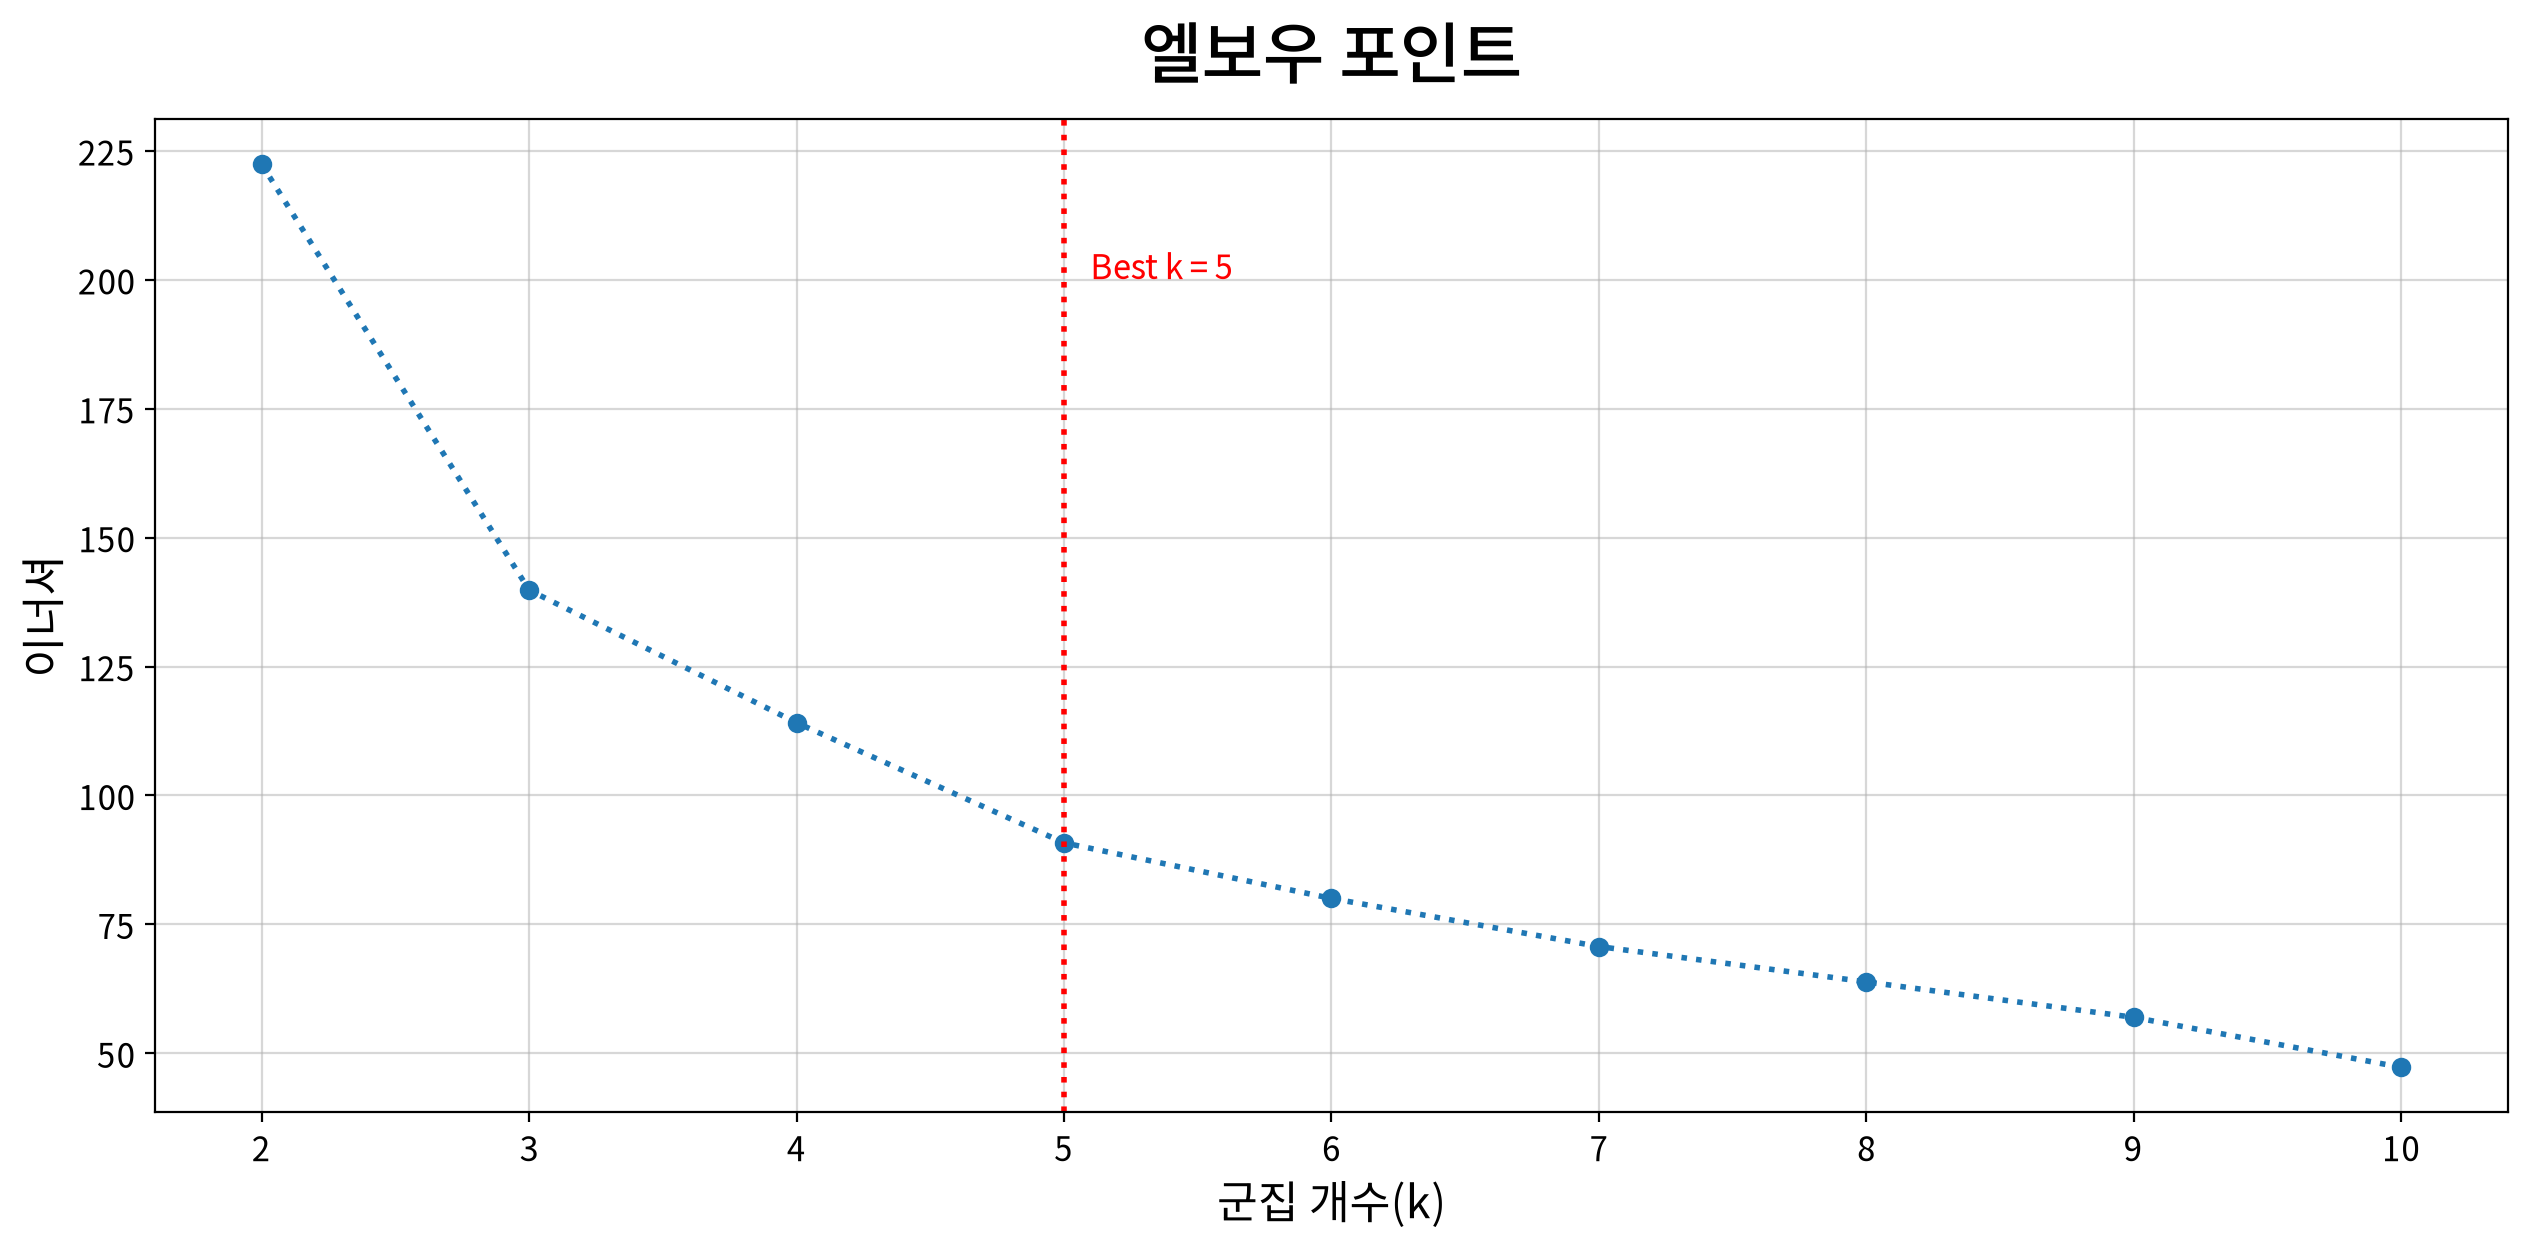

엘보우 포인트: 5


,k,이너셔,감소량
0,2,222.362,NaN
1,3,139.821,82.541
2,4,114.097,25.723
3,5,90.807,23.290
4,6,80.022,10.785
5,7,70.697,9.326
6,8,63.836,6.861
7,9,56.962,6.873
8,10,47.275,9.687


In [13]:
elbow_k, elbow_df = my_cluster.best_k_elbow(df)

print("엘보우 포인트:", elbow_k)
elbow_df

### 2. 실루엣 스코어 기반 best-k 찾기

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90          -1.87 ~ 2.49
Sepal.Width          2.00 ~ 4.40          -2.43 ~ 3.09
Petal.Length         1.00 ~ 6.90          -1.57 ~ 1.79
Petal.Width          0.10 ~ 2.50          -1.45 ~ 1.71
[실루엣] 균형지수 최대 → 최적의 k = 3(스코어 0.4599, 두께비 1.1277, 균형지수 0.2896)


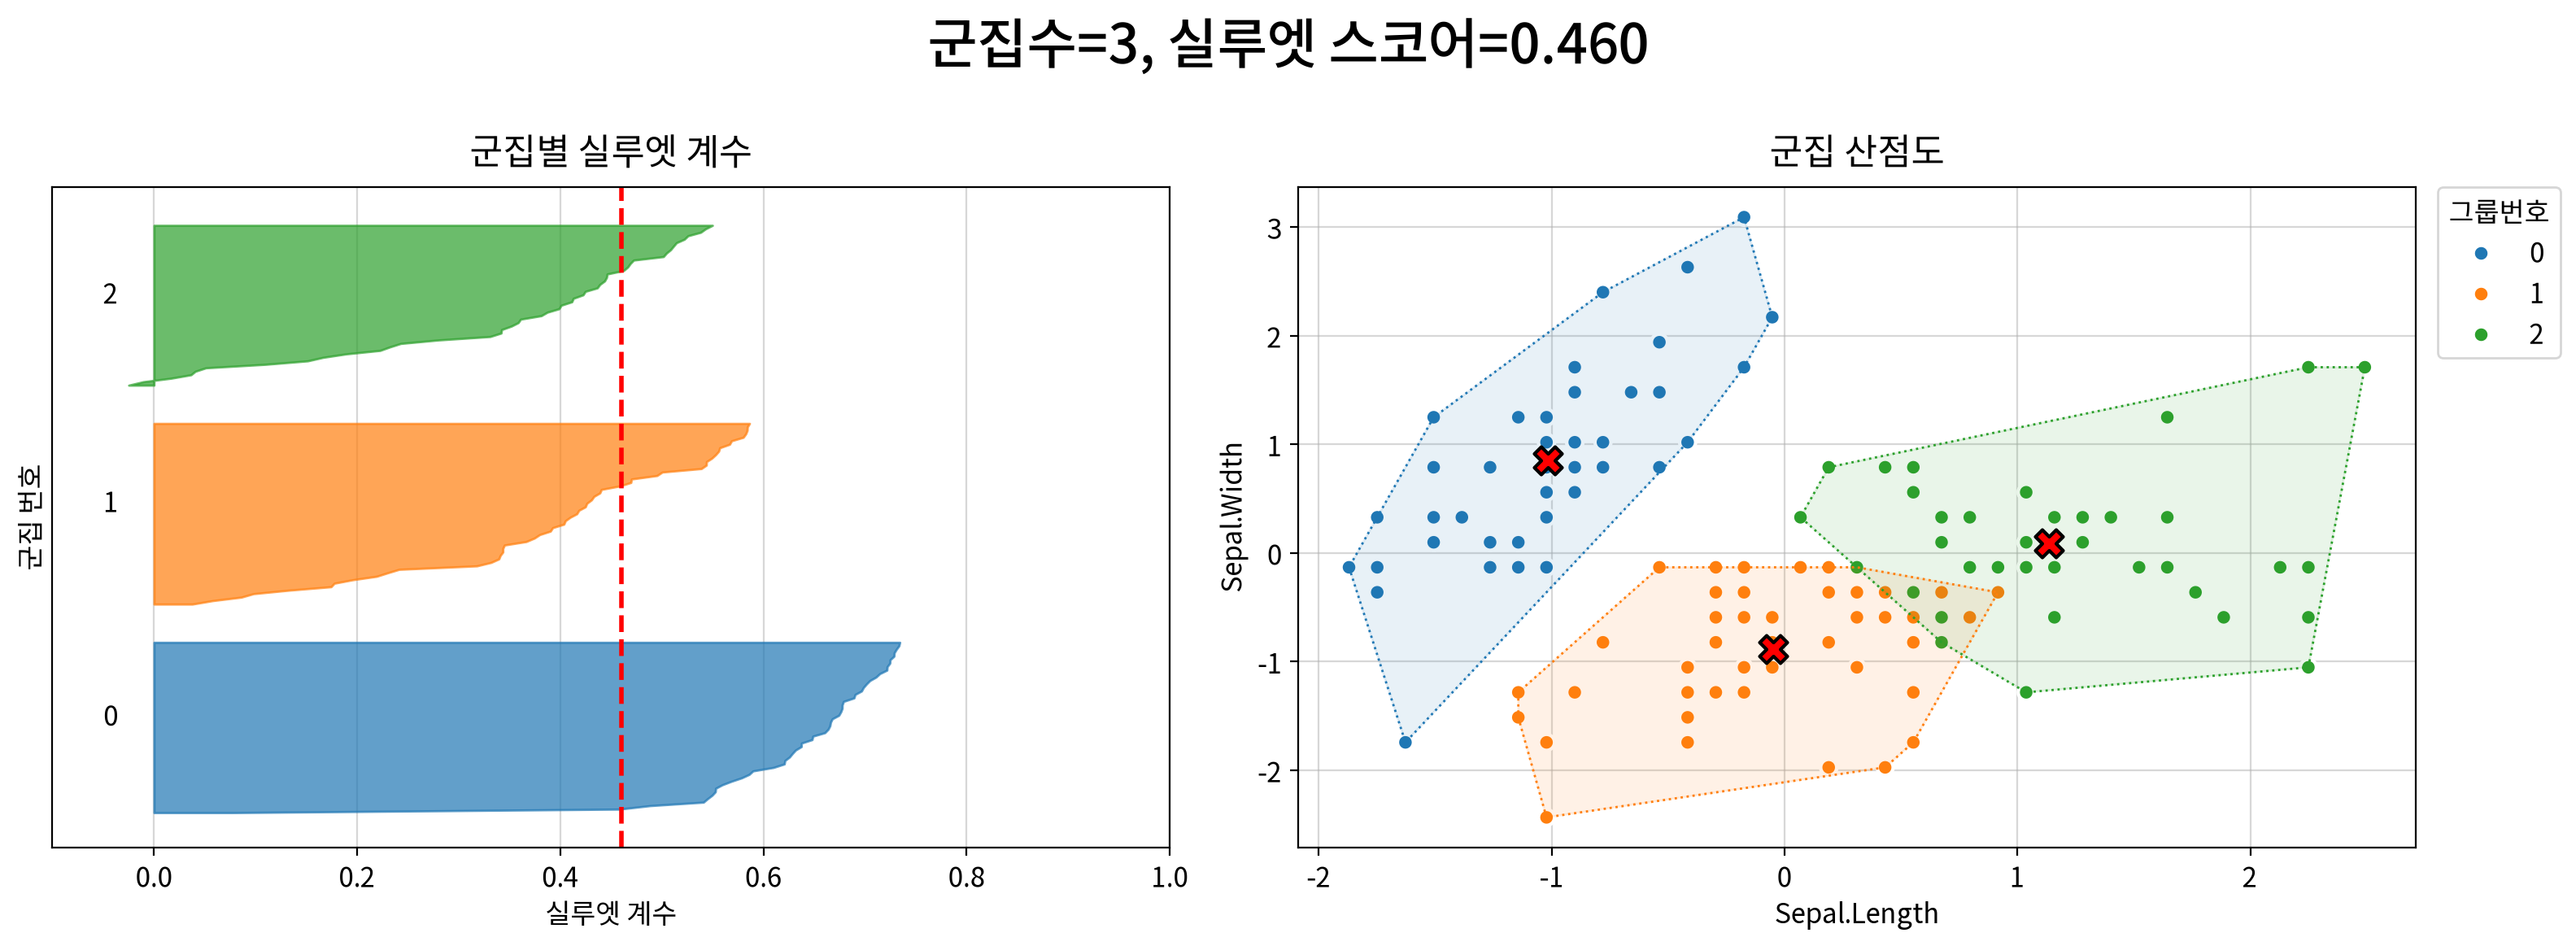

실루엣 스코어가 가장 높은 K: 3


,k,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,0.582,87.263,2.000,0.780,0.227
1,3,0.460,68.992,1.128,0.710,0.290
2,4,0.384,57.525,2.080,0.649,0.120
3,5,0.342,51.292,2.087,0.802,0.131
4,6,0.326,48.852,3.083,0.286,0.030
5,7,0.326,48.844,3.250,0.310,0.031
6,8,0.323,48.370,4.857,0.257,0.017
7,9,0.366,54.944,12.000,0.254,0.008
8,10,0.351,52.709,7.000,0.294,0.015


In [14]:
# plot_each=True 설정시 모든 k에 대해 실루엣 계수를 시각화하고,
# plot_each=False 설정시 가장 좋은 k에 대해서만 시각화한다.
sil_k, sil_df = my_cluster.best_k_silhouette(df)

print("실루엣 스코어가 가장 높은 K:", sil_k)
sil_df

### 3. 자동 최적 k 판정

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90          -1.87 ~ 2.49
Sepal.Width          2.00 ~ 4.40          -2.43 ~ 3.09
Petal.Length         1.00 ~ 6.90          -1.57 ~ 1.79
Petal.Width          0.10 ~ 2.50          -1.45 ~ 1.71


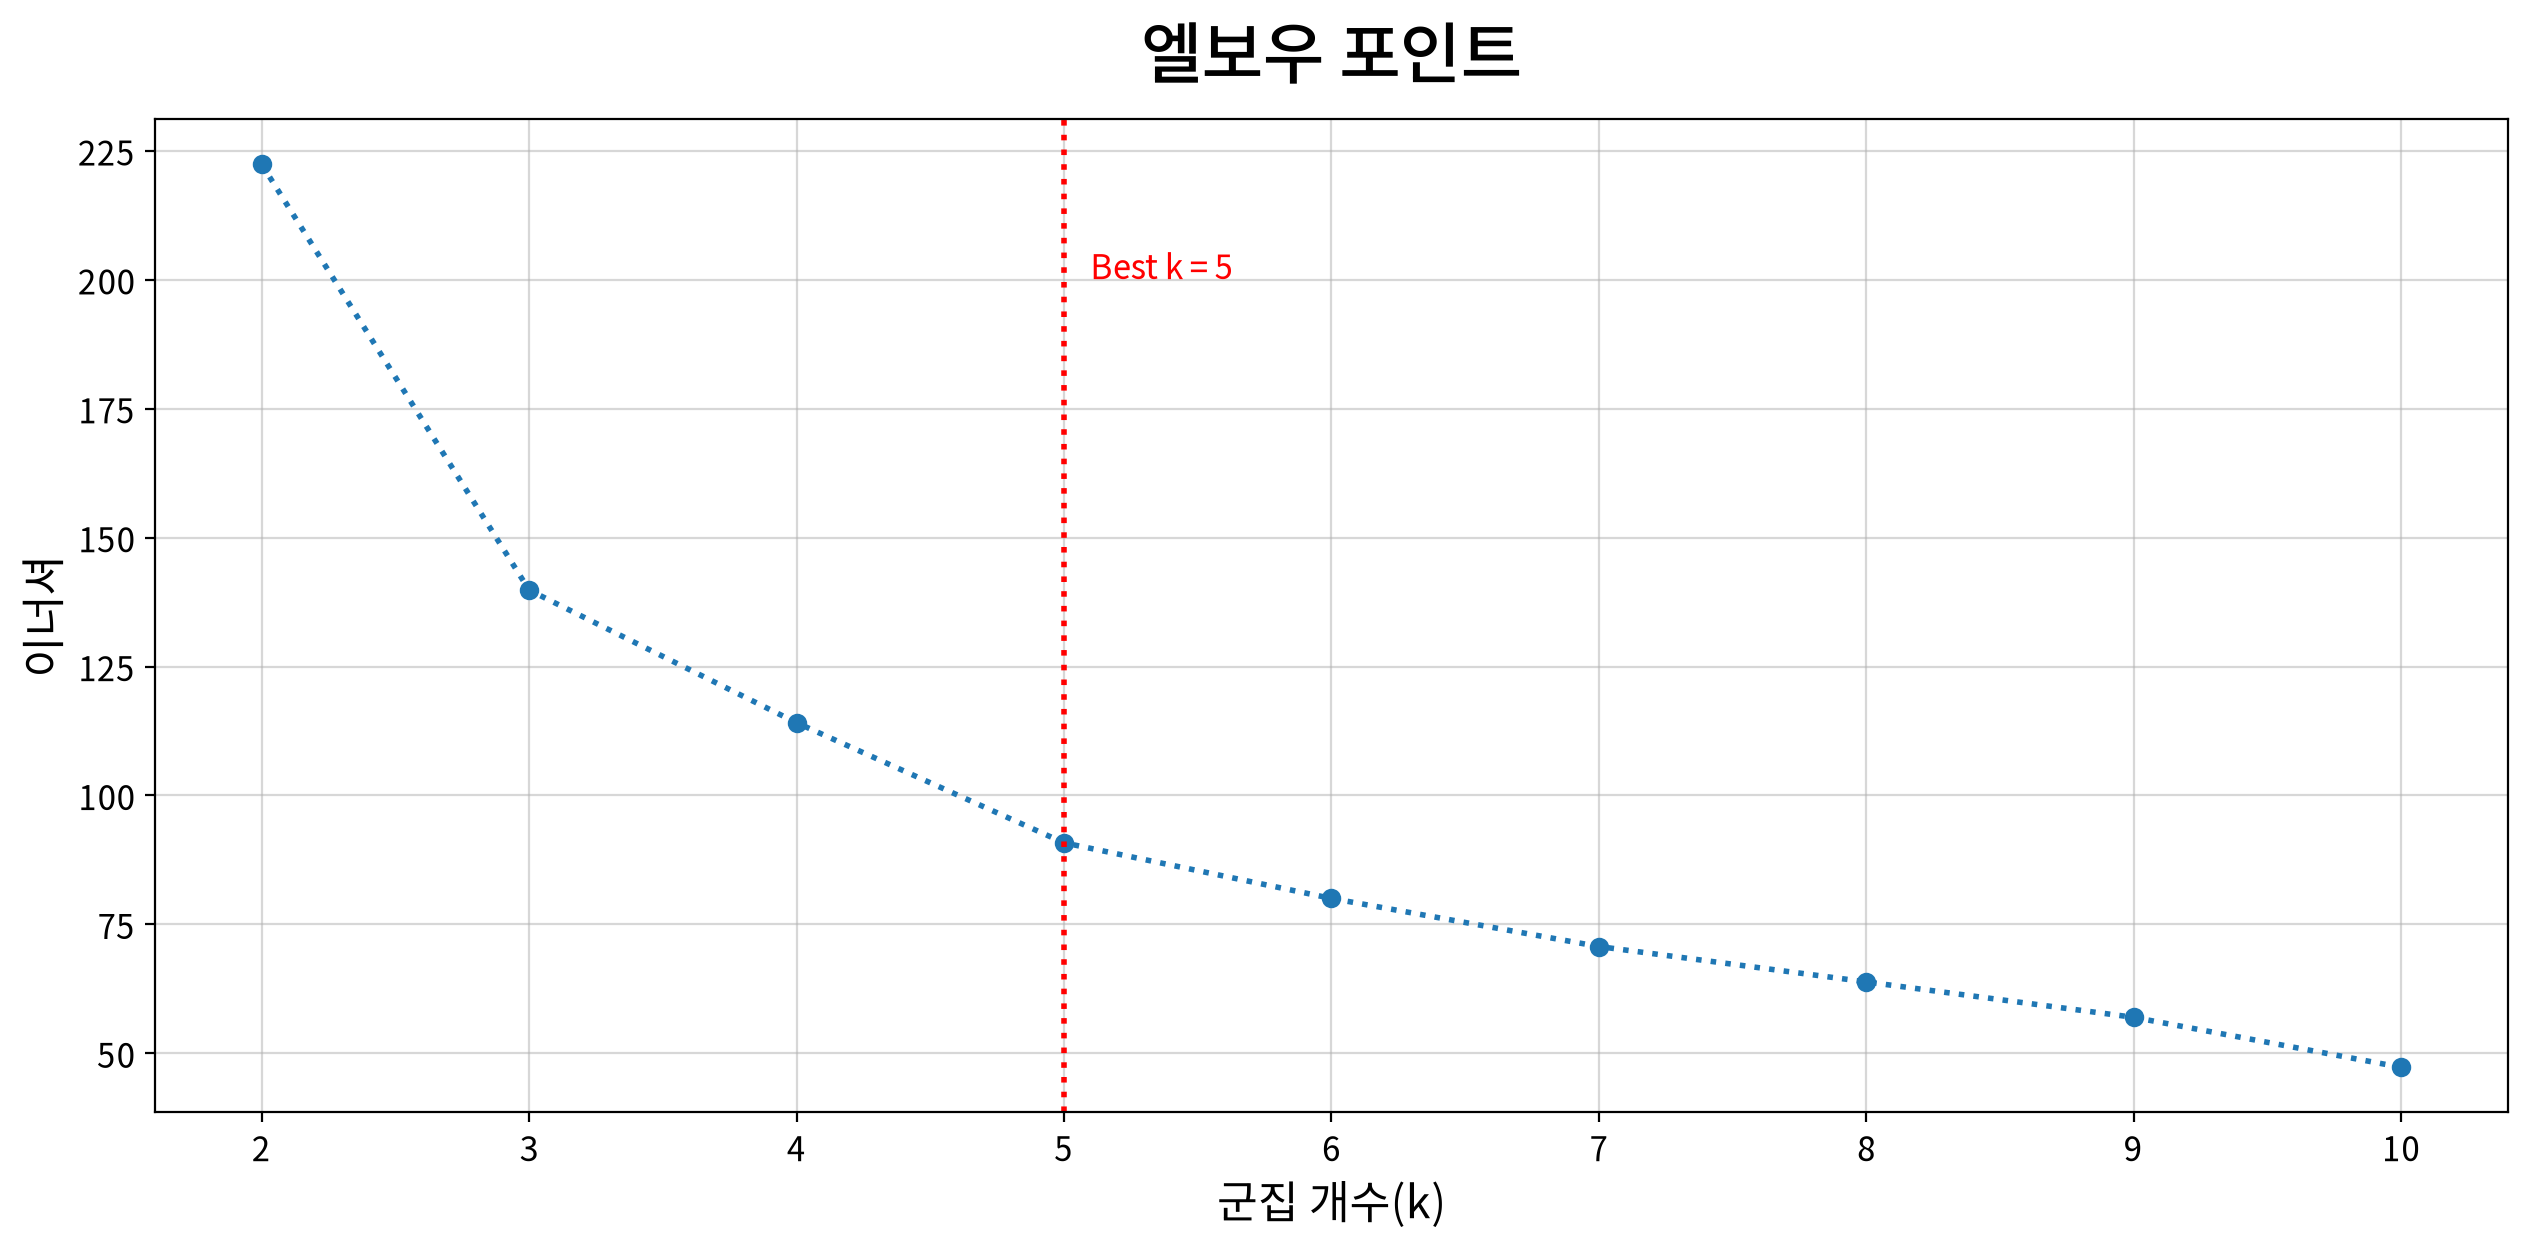

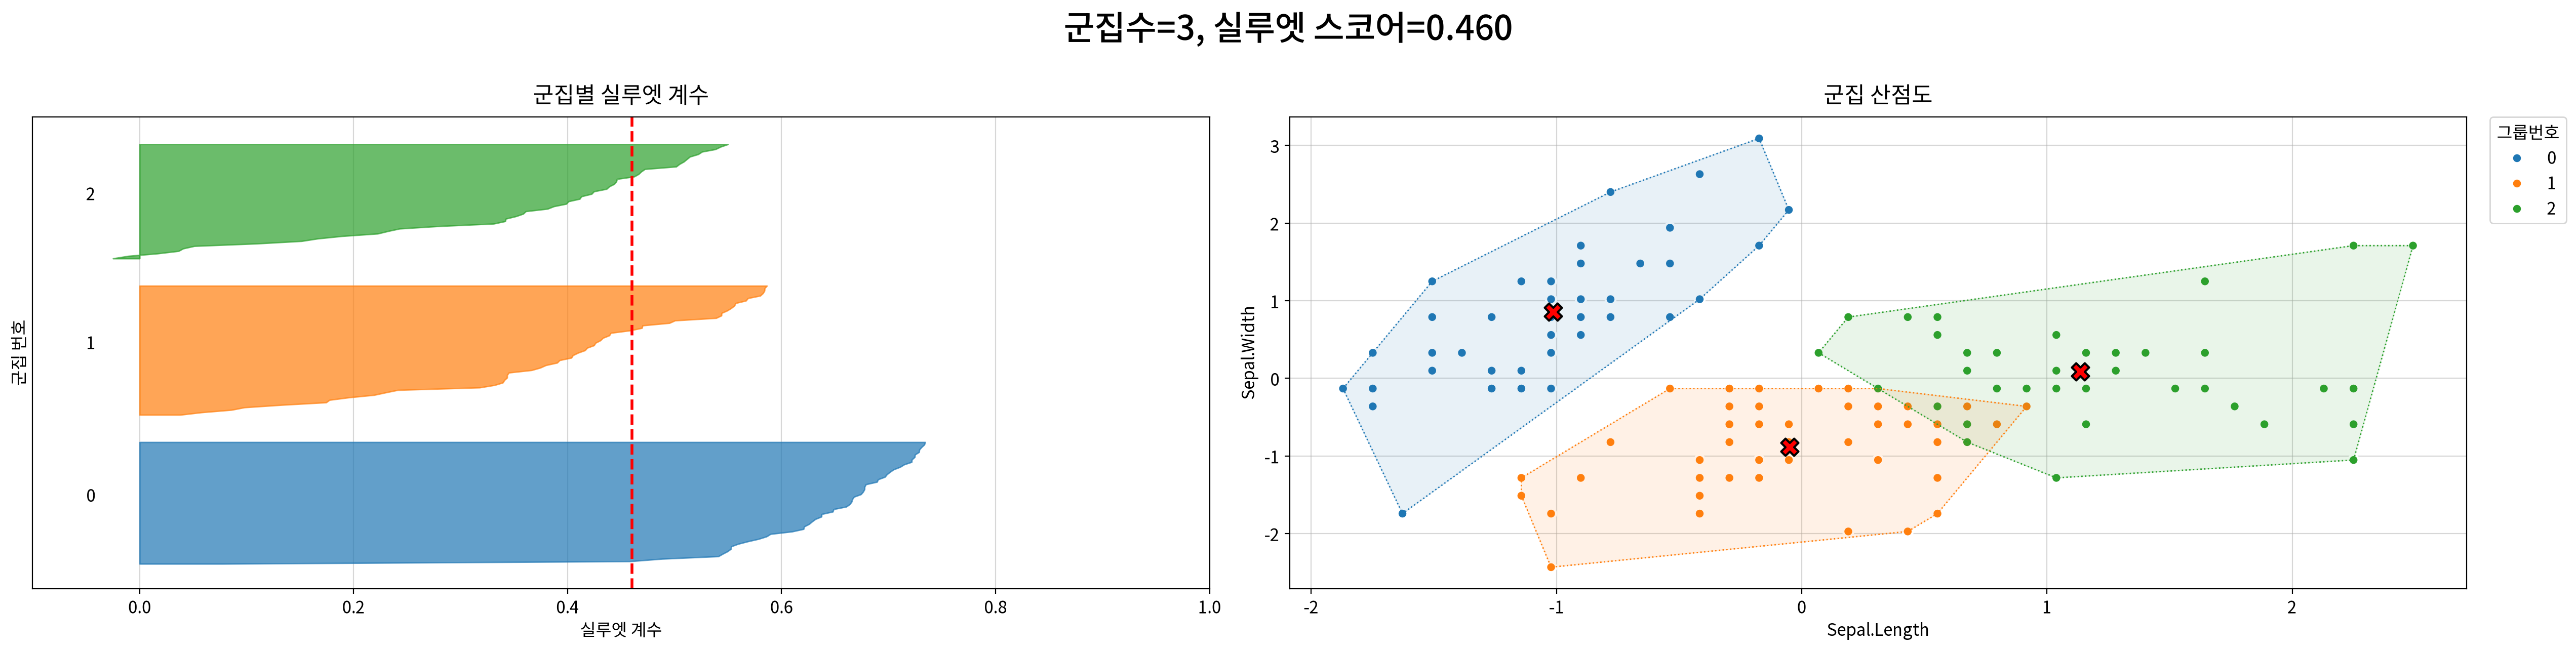

[1단계] 엘보우 포인트 : k = 5 (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 3 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
 · k = 5 : 균형지수 0.1314 (스코어 0.3419, 두께비 2.087)
 · k = 3 : 균형지수 0.2896 (스코어 0.4599, 두께비 1.1277)
------------------------------------------------------------
>>> 최종 선택: k = 3
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,222.362,NaN,0.582,87.263,2.000,0.780,0.227
1,3,139.821,82.541,0.460,68.992,1.128,0.710,0.290
2,4,114.097,25.723,0.384,57.525,2.080,0.649,0.120
3,5,90.807,23.290,0.342,51.292,2.087,0.802,0.131
4,6,80.022,10.785,0.326,48.852,3.083,0.286,0.030
5,7,70.697,9.326,0.326,48.844,3.250,0.310,0.031
6,8,63.836,6.861,0.323,48.370,4.857,0.257,0.017
7,9,56.962,6.873,0.366,54.944,12.000,0.254,0.008
8,10,47.275,9.687,0.351,52.709,7.000,0.294,0.015


In [15]:
final_k, k_df = my_cluster.best_k(df)
k_df